In [1]:
from qeep import plot
from qeep import qeutils

import matplotlib.pyplot as plt

import numpy as np

import matplotlib.pyplot as plt

import yaml
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

from qeep import fisher

import os
os.environ['PATH'] = os.path.expanduser("~/texlive/2025/bin/aarch64-linux") + ":" + os.environ['PATH']

style_path = "paper.mplstyle"
plt.style.use(style_path)

In [2]:
configuration = '../../configs/abacus/config_desi_example_forecast_base.yaml'

with open(configuration, 'r') as f:
    config = yaml.safe_load(f)

ps_main_directory = config['power_spectrum']['main_directory']
name_config = config['name']
gen_nl_power = np.loadtxt("../"+ps_main_directory+name_config+"/"+config['power_spectrum']['nonlinear'])
gen_power = np.loadtxt("../"+ps_main_directory+name_config+"/"+config['power_spectrum']['linear'])

kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']
k_samples = kr_config['k_samples']
k_min_analysis = kr_config['k_min_analysis']
k_max_analysis = kr_config['k_max_analysis']

kmin_max = 2*k_min_analysis
Ks_ = np.linspace(k_min_analysis, kmin_max, 20)
Ks__ = np.linspace(kmin_max, kmin, 200)
Ks = np.logspace(np.log10(kmin), np.log10(k_max_analysis), k_samples)
Ks = np.concatenate([Ks_, Ks__, Ks])
Ks = np.unique(Ks)
pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])

## Let's define the power spectra

In [3]:
from qeep import biases
from qeep import qeresults as qres
import jax
from jax import numpy as jnp

PL_calculated = plinf(Ks)

def plinear():
    return PL_calculated

def E_bottaro():
    z_eq = 3400
    a_eq = 1/(1+z_eq)
    a = 1.
    fchi = 1.
    factor = jnp.log(a/a_eq)-181/90
    factor *= fchi
    factor *= 6/5
    return factor

def G(epsilon, one = 1):
    E = E_bottaro()
    return 1+epsilon*E*one

def get_CG(v, asymm_shift = 1., only_asymm_shift = 0.):  
    """
    Effective biases.

    asymm_shift = 1., means we include the C^{S}_{[AB]} signature from the anti-symmetric term. If zero, this is not included.
    only_asymm_shift = 0., means that we are including G and T anti-symmetric. If 1., we exclude them. This is useful to check origin of constraints on epsilon.
    """
    e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = v
    Cg = biases.get_Cg_biases(e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)
    return Cg


def get_tot_bias_Cg(normalization, Cg, responses):
    """
    This is the overall bias coming from all the present terms, given Cg.
    """
    partials = normalization * responses * Cg[:, jnp.newaxis]
    bias = jnp.sum(partials, axis=0)
    return jnp.nan_to_num(bias)

def get_tot_bias(v, normalization, responses, asymm_shift = 1, only_asymm_shift = 0.):
    """
    This is the overall bias given your parameter vector v, the normalization of the estimator, and the responses.
    """
    Cg = get_CG(v, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)
    return get_tot_bias_Cg(normalization, Cg, responses)

def galaxy_power_spectrum(v, nshot, growth_eps = 1.):
    """
    Standard power spectrum with linear bias and shot noise.
    We also include an additional growth factor depending on epsilon.
    """
    eps, b1X = v
    return  b1X**2*plinear()*G(eps, growth_eps)**2 + nshot

def cross_galaxy_power_spectrum(vA, vB, cross_shot = 0., growth_eps = 1.):
    """
    Standard power spectrum with linear bias and shot noise.
    We also include an additional growth factor depending on epsilon.
    """
    eps, b1X = vA
    eps, b1Y = vB
    return  b1X*b1Y*plinear()*G(eps, growth_eps)**2+cross_shot
    
def reconstruction_cross_spectrum(v, b1X, normalization, responses, bisp_noise, asymm_shift = 1, only_asymm_shift = 0., growth_eps = 1.):
    """
    bisp_noise, bispectrum shot noise
    growth_eps, include growth term epsilon or not
    """
    bias = get_tot_bias(v, normalization, responses, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)
    signal = b1X*bias*plinear()*G(v[0], growth_eps)**3
    return signal + bisp_noise

def reconstruction_auto_spectrum(v, normalization, responses, var_noise, tris_noise, signal = 1., asymm_shift = 1, only_asymm_shift = 0, growth_eps = 1.,
                                normalization_2 = None, responses_2 = None):
    bias = get_tot_bias(v, normalization, responses, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)
    if normalization_2 is not None:
        bias2 = get_tot_bias(v, normalization_2, responses_2, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)
    else:
        bias2 = bias
    signal = bias*bias2*plinear()*signal*G(v[0], growth_eps)**4
    return signal + var_noise + tris_noise

In [86]:
def get_functions(QR, key, key2 = None, shot_noise_A = 1., shot_noise_B = 1., shot_noise_AB = 0., variance_factor = 1., bispectrum_factor = 1., trispectrum_factor = 1., asymm_shift = 1., only_asymm_shift = 0., growth_eps = 0., keys = ["g", "s", "t", "ga", "sa", "ta"]):
    """
    This will give me basic functions that I can use to combine spectra.

    key is some QE key.

    Could be made more efficient and less redundant....
    """   

    out_normalization_AB = QR.get_out_normalization_AB()

    keys = ["g", "s", "t", "ga", "sa", "ta"]

    if key2 is None:
        variance_noise = QR.get_get_variance()(key)*variance_factor    
        bispectrum_noise_with_B = QR.get_get_bispectrum_mixed_withB()(key)*bispectrum_factor if bispectrum_factor != 0 else 0
        bispectrum_noise = QR.get_get_bispectrum_mixed()(key)*bispectrum_factor if bispectrum_factor != 0 else 0
        trispectrum_noise = (QR.get_get_trispectrum()(key))*trispectrum_factor if trispectrum_factor != 0 else 0
        normalization = QR.get_get_norm()(key)
        
        responses = qres.get_normalization_array(key, keys, Ks, out_normalization_AB)
            
        CRR = lambda v: reconstruction_auto_spectrum(v, normalization, responses, variance_noise, trispectrum_noise, asymm_shift = asymm_shift, growth_eps = growth_eps, only_asymm_shift = only_asymm_shift) #gets reconstruction auto-spectrum

        CAA = lambda v: galaxy_power_spectrum(v[:2], shot_noise_A, growth_eps = growth_eps) #gets galaxy auto-spectrum
        CAR = lambda v, b1X: reconstruction_cross_spectrum(v, b1X, normalization, responses, bispectrum_noise, asymm_shift = asymm_shift, growth_eps = growth_eps, only_asymm_shift = only_asymm_shift) #gets cross-spectrum
        
        CBB = lambda v: galaxy_power_spectrum(v[:2], shot_noise_B, growth_eps = growth_eps)
        CBR = lambda v, b1X: reconstruction_cross_spectrum(v, b1X, normalization, responses, bispectrum_noise_with_B, asymm_shift = asymm_shift, growth_eps = growth_eps, only_asymm_shift = only_asymm_shift) #gets cross-spectrum

        CAB = lambda vA, vB: cross_galaxy_power_spectrum(vA[:2], vB[:2], cross_shot = shot_noise_AB, growth_eps = growth_eps)

        return CAA, CBB, CAR, CBR, CRR, CAB

    else:
        normalization_2 = QR.get_get_norm()(key2)
        normalization = QR.get_get_norm()(key)

        responses = qres.get_normalization_array(key, keys, Ks, out_normalization_AB)
        responses_2 = qres.get_normalization_array(key2, keys, Ks, out_normalization_AB)
        
        variance_noise_cross = QR.get_get_variance()(key, key2)*variance_factor    
        trispectrum_noise_cross = QR.get_get_trispectrum()(key, key2)*trispectrum_factor if trispectrum_factor != 0 else 0
        CRR_key_key2 = lambda v: reconstruction_auto_spectrum(v, normalization, responses, variance_noise_cross, trispectrum_noise_cross, 
                                                              asymm_shift = asymm_shift, growth_eps = growth_eps, only_asymm_shift = only_asymm_shift,
                                                             normalization_2 = normalization_2, responses_2 = responses_2)
        return CRR_key_key2

For example, we can use `get_functions` to get the CAA, CBB, CRR, CBR, CRR power spectra for the displacement estimator.

Otherwise, we could also decide to focus on the growth estimator.

Now, we define some utility functions to get spectra.

In [87]:
def get_v(vA):
    e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = vA
    b1B, b2B, bs2B = b1A, b2A, bs2A
    v = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])
    return v

def get_vA_vB(v):
    #v = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])
    
    #what we do is the following, to write less code
    #we create a vector for A
    #then, we create for B, just swapping some places
    
    e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = v
    vA = v #ok, this is my default ordering
    vB = jnp.array([e, b1B, b1A, b2B, b2A, bs2B, bs2A, bGXB, bGXA, bSXB, bSXA, bTXB, bTXA])
    return vA, vB


def get_vB_from_vA(v):
    #v = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])
    e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = v
    vB = jnp.array([e, b1B, b1A, b2B, b2A, bs2B, bs2A, bGXB, bGXA, bSXB, bSXA, bTXB, bTXA])
    return vB

def get_functions_vA_only(CAA, CAR, CRR):
    """
    This assumes I only have vA as my input when studying stuff
    vA = e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB
    """
        
    def CAA_(vA):
        return CAA(get_v(vA))

    def CAR_(vA):
            return CAR(get_v(vA))

    def CRR_(vA):
            return CRR(get_v(vA))

    return CAA_, CAR_, CRR_


def get_functions_A(CAA, CAR, CRR):
    """
    This assumes full
    v = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])
    """
        
    def CAA_(v):
        return CAA(v)

    def CAR_(v):
            return CAR(v, v[1])

    def CRR_(v):
            return CRR(v)

    return CAA_, CAR_, CRR_

def get_functions_vA_vB(CAA, CAR, CRR, CBB, CBR, CAB):
    """
    This assumes I have the full v for A and B as my input when studying stuff.
    v = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])

    I assume by convention that A follows that ordering.
    """
    
    def CAA_(v):
        return CAA(v)

    def CAR_(v):
            return CAR(v, v[1])

    def CRR_(v):
            return CRR(v)

    def CBB_(v):
        return CBB(get_vB_from_vA(v))

    def CBR_(v):
            return CBR(v, get_vB_from_vA(v)[1])

    def CAB_(v):
            return CAB(v, get_vB_from_vA(v))

    return CAA_, CAR_, CRR_, CBB_, CBR_, CAB_ 


def get_cov(CAAf, CARf, CRRf):
    @jax.jit
    def covariance_full(K_array, vA):

        n_probes = 2

        C = jnp.zeros((len(K_array), n_probes, n_probes))
        
        CAR = CARf(vA)
        
        C = C.at[:, 0, 0].set(CRRf(vA))
        C = C.at[:, 0, 1].set(CAR)
        C = C.at[:, 1, 0].set(CAR)
        C = C.at[:, 1, 1].set(CAAf(vA))
        
        return C
    
    return covariance_full


def get_cov_with_AB(CAAf, CARf, CRRf, CBBf, CBRf, CABf):
    @jax.jit
    def covariance_full(K_array, v):

        n_probes = 3

        C = jnp.zeros((len(K_array), n_probes, n_probes))
        
        CAR = CARf(v)
        CBR = CBRf(v)
        CAB = CABf(v)
        
        C = C.at[:, 0, 0].set(CRRf(v))
        C = C.at[:, 0, 1].set(CAR)
        C = C.at[:, 1, 0].set(CAR)
        C = C.at[:, 0, 2].set(CBR)
        C = C.at[:, 2, 0].set(CBR)
        C = C.at[:, 1, 1].set(CAAf(v))
        C = C.at[:, 1, 2].set(CAB)
        C = C.at[:, 2, 1].set(CAB)
        C = C.at[:, 2, 2].set(CBBf(v))
        
        return C
    
    return covariance_full

def get_cov_with_AB_R_R2(CAAf, CARf, CRRf, CBBf, CBRf, CABf, 
                         CAR2f, CBR2f, CRR2f, CR2R2f):
    @jax.jit
    def covariance_full(K_array, v):

        n_probes = 4

        C = jnp.zeros((len(K_array), n_probes, n_probes))
        
        CAR = CARf(v)
        CBR = CBRf(v)
        CAB = CABf(v)
        
        CAR2 = CAR2f(v)
        CBR2 = CBR2f(v)
        CRR2 = CRR2f(v)
        CR2R2 = CR2R2f(v)
        
        C = C.at[:, 0, 0].set(CRRf(v))
        C = C.at[:, 0, 1].set(CAR)
        C = C.at[:, 1, 0].set(CAR)
        C = C.at[:, 0, 2].set(CBR)
        C = C.at[:, 2, 0].set(CBR)
        C = C.at[:, 1, 1].set(CAAf(v))
        C = C.at[:, 1, 2].set(CAB)
        C = C.at[:, 2, 1].set(CAB)
        C = C.at[:, 2, 2].set(CBBf(v))

        C = C.at[:, 1, 3].set(CAR2)
        C = C.at[:, 3, 1].set(CAR2)
        C = C.at[:, 2, 3].set(CBR2)
        C = C.at[:, 3, 2].set(CBR2)
        C = C.at[:, 3, 0].set(CRR2)
        C = C.at[:, 0, 3].set(CRR2)
        C = C.at[:, 3, 3].set(CR2R2)
        
        return C
    
    return covariance_full


def get_cov_with_AB_ps_only(CAAf, CBBf, CABf):
    @jax.jit
    def covariance_full(K_array, v):

        n_probes = 2

        C = jnp.zeros((len(K_array), n_probes, n_probes))

        CAB = CABf(v)
        
        C = C.at[:, 0, 0].set(CAAf(v))
        C = C.at[:, 0, 1].set(CAB)
        C = C.at[:, 1, 0].set(CAB)
        C = C.at[:, 1, 1].set(CBBf(v))
        
        return C
    
    return covariance_full


def get_Ofuncs(CAAf, CARf, CRRf):
    Ofunc = lambda K_arr, v: CARf(v)
    variance_func = lambda K_arr, v: CAAf(v)*CRRf(v)+CARf(v)**2
    return Ofunc, variance_func

def get_Ofuncs_A_cov(CAAf, CARf, CRRf):
    def Ofunc(K_arr, v):
        return jnp.array([CARf(v)]).T
    def variance_func_cross_cov(K_arr, v):
        C = jnp.zeros((CAAf(v).shape[0], 1, 1))
        C = C.at[:, 0, 0].set(CAAf(v)*CRRf(v)+CARf(v)**2) 
        return C  
    return Ofunc, variance_func_cross_cov


def get_Ofuncs_AB(CAAf, CBBf, CABf, CARf, CBRf, CRRf):
    def Ofunc(K_arr, v):
        return jnp.array([CARf(v), CBRf(v)]).T
    def variance_func_cross_cov(K_arr, v):
        C = jnp.zeros((CAAf(v).shape[0], 2, 2))
        C = C.at[:, 0, 0].set(CAAf(v)*CRRf(v)+CARf(v)**2) 
        C = C.at[:, 1, 1].set(CBBf(v)*CRRf(v)+CBRf(v)**2)
        diag = CABf(v)*CRRf(v)+CARf(v)*CBRf(v)
        C = C.at[:, 0, 1].set(diag) 
        C = C.at[:, 1, 0].set(diag) 
        return C
    
    return Ofunc, variance_func_cross_cov


def get_Ofuncs_AB_proper(CAAf, CBBf, CABf, CARf, CBRf, CRRf):
    def Ofunc(K_arr, v):
        return jnp.array([CAAf(v), CBBf(v), CABf(v), CARf(v), CBRf(v)]).T
    def variance_func_cross_cov(K_arr, v):
        C = jnp.zeros((CAAf(v).shape[0], 5, 5))
        C = C.at[:, 0, 0].set(2*CAAf(v)**2)
        C = C.at[:, 1, 1].set(2*CBBf(v)**2) 
        C = C.at[:, 2, 2].set(CAAf(v)*CBBf(v)+CABf(v)**2) 
        C = C.at[:, 3, 3].set(CRRf(v)*CAAf(v)+CARf(v)**2) 
        C = C.at[:, 4, 4].set(CRRf(v)*CBBf(v)+CBRf(v)**2) 

        #cross cov with AA
        C = C.at[:, 0, 1].set(2*CABf(v)**2) #AA-BB
        C = C.at[:, 1, 0].set(C[:, 0, 1])

        C = C.at[:, 0, 2].set(2*CAAf(v)*CABf(v)) #AA-AB
        C = C.at[:, 2, 0].set(C[:, 0, 2])

        C = C.at[:, 0, 3].set(2*CAAf(v)*CARf(v)) #AA-AR
        C = C.at[:, 3, 0].set(C[:, 0, 3])

        C = C.at[:, 0, 4].set(2*CABf(v)*CARf(v)) #AA-BR
        C = C.at[:, 4, 0].set(C[:, 0, 4])


        #cross cov with BB

        C = C.at[:, 1, 2].set(2*CBBf(v)*CABf(v)) #BB-AB
        C = C.at[:, 2, 1].set(C[:, 1, 2])

        C = C.at[:, 1, 3].set(2*CABf(v)*CBRf(v)) #BB-AR
        C = C.at[:, 3, 1].set(C[:, 1, 3])

        C = C.at[:, 1, 4].set(2*CBBf(v)*CBRf(v)) #BB-BR
        C = C.at[:, 4, 1].set(C[:, 1, 4])

        #cross cov with AB

        C = C.at[:, 2, 3].set(CAAf(v)*CBRf(v)+CARf(v)*CABf(v)) #AB-AR
        C = C.at[:, 3, 2].set(C[:, 2, 3])

        C = C.at[:, 2, 4].set(CABf(v)*CBRf(v)+CARf(v)*CBBf(v)) #AB-BR
        C = C.at[:, 4, 2].set(C[:, 2, 4])

        #cross cov with AR

        C = C.at[:, 3, 4].set(CABf(v)*CRRf(v)+CARf(v)*CBRf(v)) #AR-BR
        C = C.at[:, 4, 3].set(C[:, 3, 4])
        
        return C
    
    return Ofunc, variance_func_cross_cov


def get_Ofuncs_AB_joint(CAAf, CBBf, CABf, CARf, CBRf, CRRf):
    @jax.jit
    def Ofunc(K_arr, v):
        return jnp.array([CAAf(v), CBBf(v), CABf(v), CARf(v), CBRf(v), CRRf(v)]).T
    @jax.jit
    def variance_func_cross_cov(K_arr, v):
        C = jnp.zeros((CAAf(v).shape[0], 6, 6))

        C = C.at[:, 0, 0].set(2*CAAf(v)**2) 
        C = C.at[:, 1, 1].set(2*CBBf(v)**2) 
        C = C.at[:, 2, 2].set(CABf(v)**2+CAAf(v)*CBBf(v))  #cov of AB
        C = C.at[:, 3, 3].set(CAAf(v)*CRRf(v)+CARf(v)**2)  #cov of AR
        C = C.at[:, 4, 4].set(CBBf(v)*CRRf(v)+CBRf(v)**2)  #cov of BR
        C = C.at[:, 5, 5].set(2*CRRf(v)**2)  #cov of RR

        diag = 2*CABf(v)**2 #cov AA - BB
        C = C.at[:, 0, 1].set(diag) 
        C = C.at[:, 1, 0].set(diag) 

        diag = 2*CABf(v)*CAAf(v) #cov AA - AB
        C = C.at[:, 0, 2].set(diag) 
        C = C.at[:, 2, 0].set(diag) 

        diag = 2*CARf(v)*CAAf(v) #cov AA - AR
        C = C.at[:, 0, 3].set(diag) 
        C = C.at[:, 3, 0].set(diag) 

        diag = 2*CARf(v)*CABf(v) #cov AA - BR
        C = C.at[:, 0, 4].set(diag) 
        C = C.at[:, 4, 0].set(diag) 

        diag = 2*CARf(v)**2 #cov AA - RR
        C = C.at[:, 0, 5].set(diag) 
        C = C.at[:, 5, 0].set(diag) 

        diag = 2*CABf(v)*CBBf(v) #cov BB - AB
        C = C.at[:, 1, 2].set(diag) 
        C = C.at[:, 2, 1].set(diag) 

        diag = 2*CBRf(v)*CABf(v) #cov BB - AR
        C = C.at[:, 1, 3].set(diag) 
        C = C.at[:, 3, 1].set(diag) 

        diag = 2*CBRf(v)*CBBf(v) #cov BB - BR
        C = C.at[:, 1, 4].set(diag) 
        C = C.at[:, 4, 1].set(diag) 

        diag = 2*CBRf(v)**2 #cov BB - RR
        C = C.at[:, 1, 5].set(diag) 
        C = C.at[:, 5, 1].set(diag) 

        diag = CAAf(v)*CBRf(v)+CARf(v)*CABf(v) #cov AB - AR
        C = C.at[:, 2, 3].set(diag) 
        C = C.at[:, 3, 2].set(diag) 

        diag = CABf(v)*CBRf(v)+CARf(v)*CBBf(v) #cov AB - BR
        C = C.at[:, 2, 4].set(diag) 
        C = C.at[:, 4, 2].set(diag) 

        diag = 2*CARf(v)*CBRf(v) #cov AB - RR
        C = C.at[:, 2, 5].set(diag) 
        C = C.at[:, 5, 2].set(diag) 

        diag = CARf(v)*CBRf(v)+CRRf(v)*CABf(v) #cov AR - BR
        C = C.at[:, 3, 4].set(diag) 
        C = C.at[:, 4, 3].set(diag) 

        diag = 2*CARf(v)*CRRf(v) #cov AR - RR
        C = C.at[:, 3, 5].set(diag) 
        C = C.at[:, 5, 3].set(diag) 

        diag = 2*CBRf(v)*CRRf(v) #cov BR - RR
        C = C.at[:, 4, 5].set(diag) 
        C = C.at[:, 5, 4].set(diag) 

        return C
    
    return Ofunc, variance_func_cross_cov

### Let's make a simple test

In [88]:
configuration = '../../configs/abacus/config_desi_example_forecast_base.yaml'

with open(configuration, 'r') as f:
    config = yaml.safe_load(f)
QR = qres.QEResults(config, relative_path="../.")

#plt.loglog(Ks, QR.get_get_bispectrum_mixed_withB()("n"))
#plt.loglog(Ks, QR.get_get_bispectrum_mixed()("n"))


biases_dict = config["bias"]
number_density = config["number_density"]

nbar_A = number_density["nbar_A"]
nbar_B = number_density["nbar_B"]

b1A = biases_dict["b10_A"]
b1B = biases_dict["b10_B"]
e = 1e-3

b2A, b2B = -0.3, -0.3
bs2A, bs2B = biases.bs2_coev(b1A), biases.bs2_coev(b1B)
bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = 2, 1, 2, 1, 2, 1

keys = ["g", "s", "t", "ga", "sa", "ta"]

v_fiducial = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])

#vA_fiducial = jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]) #fiducial point
#vB_fiducial = jnp.array([e, b1B, b2B, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]) #fiducial point


In [125]:
factor_boosting_A = 0.
factor_boosting_B = 0.


asymm_shift = 1.
trispectrum_factor = 1.*factor_boosting_A
bispectrum_factor = 1.*factor_boosting_A
variance_factor = 1.*factor_boosting_A

growth_eps = 0.
only_asymm_shift = 0.
shot_noise_A = 1/nbar_A*factor_boosting_A
shot_noise_B = 1/nbar_B*factor_boosting_B
shot_noise_AB = 0

key = "n"
key2 = None

CAA, CBB, CAR, CBR, CRR, CAB = get_functions(QR, key, key2 = key2, 
              shot_noise_A = shot_noise_A, shot_noise_B = shot_noise_B, shot_noise_AB = shot_noise_AB,
              variance_factor = variance_factor, bispectrum_factor = bispectrum_factor, 
              trispectrum_factor = trispectrum_factor, asymm_shift = asymm_shift, 
              only_asymm_shift = only_asymm_shift, growth_eps = growth_eps, keys = keys)

key2 = "g"
_, _, CAR2, CBR2, CR2R2, _ = get_functions(QR, key2, key2 = None, 
              shot_noise_A = shot_noise_A, shot_noise_B = shot_noise_B, shot_noise_AB = shot_noise_AB,
              variance_factor = variance_factor, bispectrum_factor = bispectrum_factor, 
              trispectrum_factor = trispectrum_factor, asymm_shift = asymm_shift, 
              only_asymm_shift = only_asymm_shift, growth_eps = growth_eps, keys = keys)

key2 = "g"
CRR2 = get_functions(QR, key, key2 = key2, 
              shot_noise_A = shot_noise_A, shot_noise_B = shot_noise_B, shot_noise_AB = shot_noise_AB,
              variance_factor = variance_factor, bispectrum_factor = bispectrum_factor, 
              trispectrum_factor = trispectrum_factor, asymm_shift = asymm_shift, 
              only_asymm_shift = only_asymm_shift, growth_eps = growth_eps, keys = keys)

In [126]:
CAAf, CARf, CRRf, CBBf, CBRf, CABf = get_functions_vA_vB(CAA, CAR, CRR, CBB, CBR, CAB)

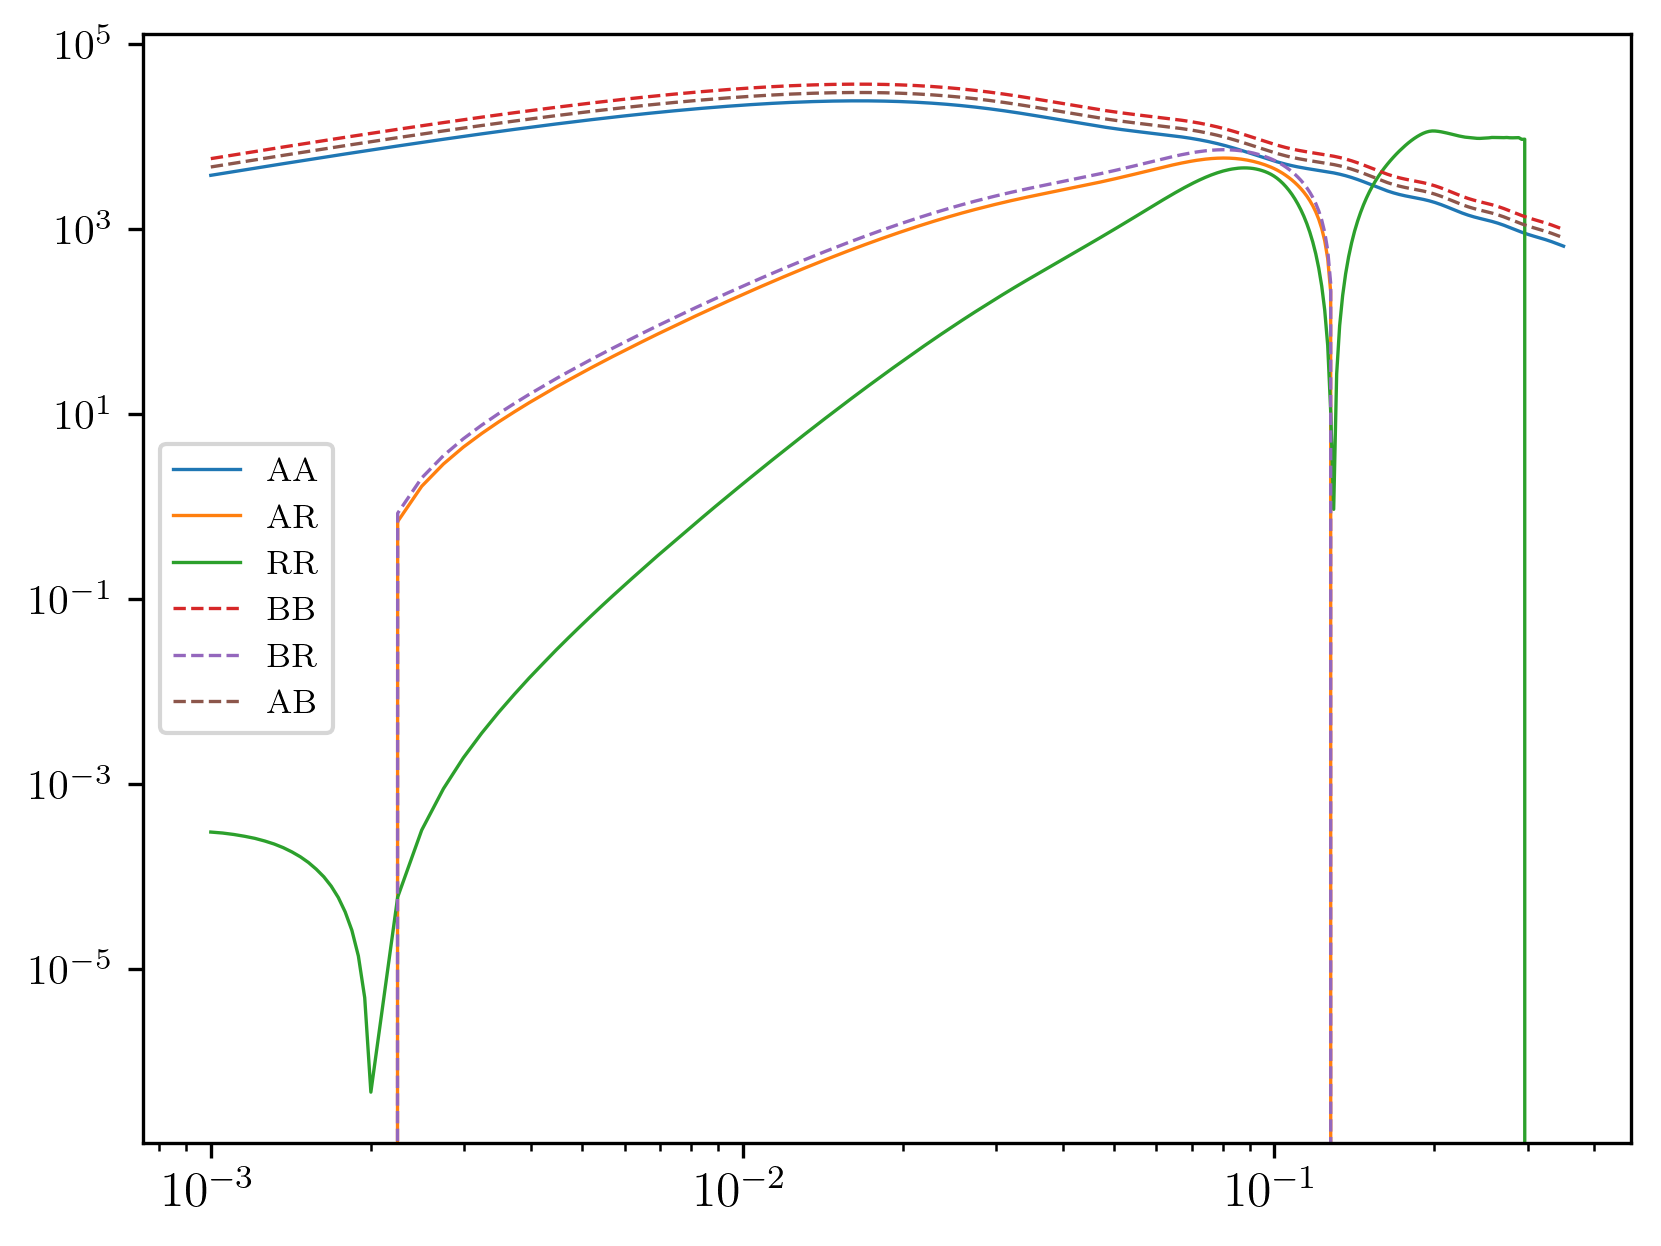

In [127]:
labels = ["AA", "AR", "RR", "BB", "BR", "AB"]
for i, qty in enumerate([CAAf, CARf, CRRf, CBBf, CBRf, CABf]):
    if i == len(labels)-1:
        plt.loglog(Ks, qty(v_fiducial), label = labels[i], ls = "--" if "B" in labels[i] else "-")
    else:
        plt.loglog(Ks, qty(get_vB_from_vA(v_fiducial)), label = labels[i], ls = "--" if "B" in labels[i] else "-")
plt.legend()

In [128]:
full_AB_cov = get_cov_with_AB(*get_functions_vA_vB(CAA, CAR, CRR, CBB, CBR, CAB))
full_AA_cov = get_cov(*get_functions_A(CAA, CAR, CRR))
full_AA_cov_vA_only = get_cov(*get_functions_vA_only(CAA, CAR, CRR))

CAAf, CARf, CRRf, CBBf, CBRf, CABf = get_functions_vA_vB(CAA, CAR, CRR, CBB, CBR, CAB)
_, CAR2f, CR2R2f, _, CBR2f, _ = get_functions_vA_vB(CAA, CAR2, CR2R2, CBB, CBR2, CAB)
CRR2f = CRR2
full_ABG_cov = get_cov_with_AB_R_R2(CAAf, CARf, CRRf, CBBf, CBRf, CABf, 
                         CAR2f, CBR2f, CRR2f, CR2R2f)

Cfull_AB = full_AB_cov(Ks, v_fiducial)
Cfull_A = full_AA_cov(Ks, v_fiducial)

cov_AB_ps = get_cov_with_AB_ps_only(CAAf, CBBf, CABf)

import itertools
combs = itertools.combinations_with_replacement([0, 1], 2)
np.all([jnp.allclose(Cfull_AB[:, ind1, ind2], Cfull_A[:, ind1, ind2]) for (ind1, ind2) in combs])

True

In [129]:
import sympy as sp
from sympy import symbols, Matrix, trace, simplify, diff

import jax
import sympy
import sympy2jax
from jax import numpy as jnp

class FisherCov():
    def __init__(self, dim=3):
        self.dim = dim
        self._build_symbols(dim)
        self._build_covariance_matrix()
        F = self._build_fisher_element()
        self.F = sympy2jax.SymbolicModule(F)
    
    def _build_symbols(self, dim=3):
        # Create symbols only for upper triangular part (including diagonal)
        self.P = [sp.Symbol(f"P_{{{i}{j}}}") for i in range(1, dim+1) for j in range(i, dim+1)]
        self.dP_m = [sp.Symbol(f"dP_{{{i}{j}}}/dtheta_m") for i in range(1, dim+1) for j in range(i, dim+1)]
        self.dP_n = [sp.Symbol(f"dP_{{{i}{j}}}/dtheta_n") for i in range(1, dim+1) for j in range(i, dim+1)]
    
    def _get_symbol_index(self, i, j):
        """Convert matrix indices (i,j) to the index in the flattened upper triangular list"""
        # Ensure i <= j for upper triangular
        if i > j:
            i, j = j, i
        
        # Calculate the index in the flattened upper triangular array
        # For row i (0-indexed), we skip i*(2n-i-1)/2 elements from previous rows
        # Then add (j-i) for the column offset
        return i * self.dim - i * (i + 1) // 2 + j
    
    def _build_covariance_matrix(self):
        def matrix_element(i, j):
            idx = self._get_symbol_index(i, j)
            return self.P[idx]
        
        def matrix_element_m(i, j):
            idx = self._get_symbol_index(i, j)
            return self.dP_m[idx]
            
        def matrix_element_n(i, j):
            idx = self._get_symbol_index(i, j)
            return self.dP_n[idx]
        
        # Build symmetric matrices
        self.C = sp.Matrix(self.dim, self.dim, matrix_element)
        self.C_inv = self.C.inv()
        self.dC_dtheta_m = sp.Matrix(self.dim, self.dim, matrix_element_m)
        self.dC_dtheta_n = sp.Matrix(self.dim, self.dim, matrix_element_n)
    
    def _build_fisher_element(self):
        product1 = self.dC_dtheta_m * self.C_inv
        product2 = self.dC_dtheta_n * self.C_inv
        trace_argument = product1 * product2
        return sp.Rational(1, 2) * sp.trace(trace_argument).simplify()
    
    def _build_derivative_from_covariance_function(self, Cfunc, v, K_array):
        dC_dv = jax.jacfwd(Cfunc, argnums=1)  # (n_modes, nprobes, nprobes, n_params)
        return dC_dv(K_array, v)
    
    def _pars_function_valuse(self, Cfunc, v, K_array):
        C = Cfunc(K_array, v)
        dC_dv = self._build_derivative_from_covariance_function(Cfunc, v, K_array)
        P_kwargs = {f"P_{{{i}{j}}}": C[:, i-1, j-1] for i in range(1, self.dim+1) for j in range(i, self.dim+1)}
        dP_kwargs = {f"dP_{{{i}{j}}}/dtheta_m": dC_dv[:, i-1, j-1, :] for i in range(1, self.dim+1) for j in range(i, self.dim+1)}
        return {**P_kwargs, **dP_kwargs}
    
    def _evaluate_fisher(self, Cfunc, v, K_array):
        kwargs = self._pars_function_valuse(Cfunc, v, K_array)
        temp = {k: v for k, v in kwargs.items()}
        number_pars = len(v)
        F_array = jnp.zeros((K_array.size, number_pars, number_pars))
        for m in range(0, number_pars):
            for n in range(m, number_pars):
                for i in range(1, self.dim+1):
                    for j in range(i, self.dim+1):
                        temp[f"dP_{{{i}{j}}}/dtheta_m"] = kwargs[f"dP_{{{i}{j}}}/dtheta_m"][:, m]
                        temp[f"dP_{{{i}{j}}}/dtheta_n"] = kwargs[f"dP_{{{i}{j}}}/dtheta_m"][:, n]
                F_array = F_array.at[:, m, n].set(self.F(**temp))
                F_array = F_array.at[:, n, m].set(F_array[:, m, n])
        return F_array
    
    def __call__(self, Cfunc, v, K_array):
        return self._evaluate_fisher(Cfunc, v, K_array)


In [130]:
def is_pos_def(x):
    return jnp.all(jnp.linalg.eigvals(x) > 0)
    
#let's check invertibility of matrix
is_pos_def(Cfull_AB[30]), Cfull_AB[30].shape

(Array(False, dtype=bool), (3, 3))

In [131]:
F_AB = fisher.fisher_per_mode(v_fiducial, Ks, full_AB_cov)
F_ABG = fisher.fisher_per_mode(v_fiducial, Ks, full_ABG_cov)
#F_AA_vA_only = fisher.fisher_per_mode(vA_fiducial, Ks, full_AA_cov_vA_only)

O, Ovar = get_Ofuncs(CAAf, CARf, CRRf)
F_cross = fisher.fisher_per_mode_single(v_fiducial, Ks, O, Ovar)
F_cross = jnp.nan_to_num(F_cross)
O_AB, Ovar_AB = get_Ofuncs_AB(CAAf, CBBf, CABf, CARf, CBRf, CRRf)
F_cross_AB = fisher.fisher_per_mode_single_with_covariance(v_fiducial, Ks, O_AB, Ovar_AB)
F_cross_AB = jnp.nan_to_num(F_cross_AB)
O_A_cov, Ovar_A_cov  = get_Ofuncs_A_cov(CAAf, CARf, CRRf)
F_cross_cov = fisher.fisher_per_mode_single_with_covariance(v_fiducial, Ks, O_A_cov, Ovar_A_cov)
F_cross_cov = jnp.nan_to_num(F_cross_cov)

O_cross_proper, Ovar_cross_proper = get_Ofuncs_AB_proper(CAAf, CBBf, CABf, CARf, CBRf, CRRf)
F_cross_cov_proper = fisher.fisher_per_mode_single_with_covariance(v_fiducial, Ks, O_cross_proper, Ovar_cross_proper)
F_cross_cov_proper = jnp.nan_to_num(F_cross_cov_proper)

O_joint_cov, Ovar_joint_cov  = get_Ofuncs_AB_joint(CAAf, CBBf, CABf, CARf, CBRf, CRRf)
F_joint_cov = fisher.fisher_per_mode_single_with_covariance(v_fiducial, Ks, O_joint_cov, Ovar_joint_cov)
F_joint_cov = jnp.nan_to_num(F_joint_cov)

In [132]:
F_AB_ps = fisher.fisher_per_mode(v_fiducial, Ks, cov_AB_ps)

In [133]:
(b1A**2*PL_calculated)[0], (b1B**2*PL_calculated)[0], (b1A*b1B*PL_calculated)[0]

(Array(5727.73104986, dtype=float64),
 Array(3781.19745088, dtype=float64),
 Array(4653.78147801, dtype=float64))

In [134]:
out_normalization_AB = QR.get_out_normalization_AB()
normalization = QR.get_get_norm()(key)
responses = qres.get_normalization_array(key, keys, Ks, out_normalization_AB)
Cg = get_CG(v_fiducial)
tot_bias = get_tot_bias_Cg(normalization, Cg, responses)

In [135]:
(b1A**2*PL_calculated)[0]*(b1B**2*PL_calculated)[0]-(b1A*b1B*PL_calculated)[0]**2

Array(3.7252903e-09, dtype=float64)

In [136]:
np.array(cov_AB_ps(Ks, v_fiducial)[0], dtype = np.float128)

array([[5727.73104986, 4653.78147801],
       [4653.78147801, 3781.19745088]], dtype=float128)

In [137]:
(tot_bias*tot_bias*PL_calculated)[0]

Array(0.00093697, dtype=float64)

In [138]:
CCC = Cfull_AB[0]
i, j = 2, 2
CCC = CCC.at[i, j].set(Cfull_AB[0][i, j]+100)
CCC = CCC.at[j, i].set(Cfull_AB[0][i, j]+100)
jnp.linalg.det(Cfull_AB[0]), jnp.linalg.det(CCC)

(Array(-1.09139364e-11, dtype=float64), Array(-7.27595761e-12, dtype=float64))

<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_294326/3067373586.py:28: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sigma$")


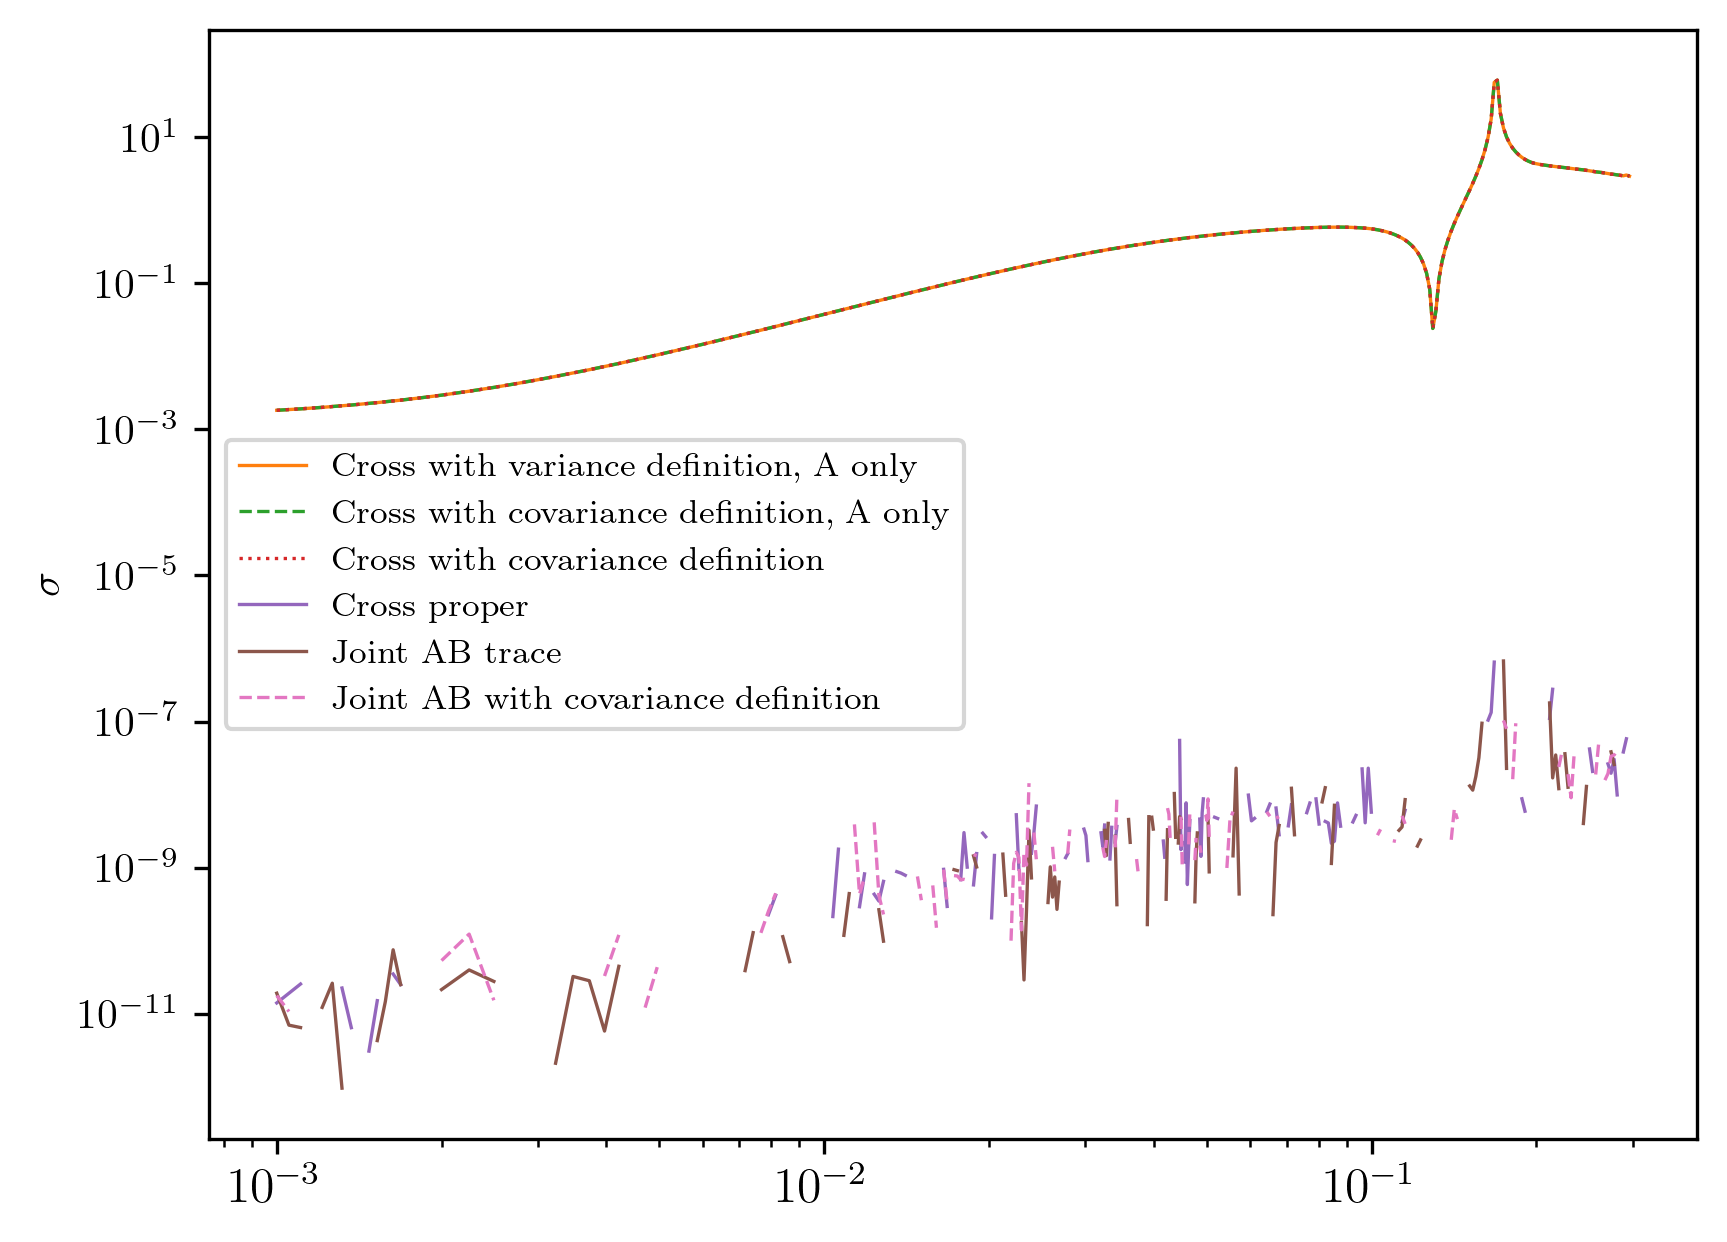

In [143]:
#v_fiducial = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])
index = 0

plt.plot(Ks, F_AB_ps[:, index, index]**-0.5)

#plt.loglog(Ks, F_AA[:, index, index]**-0.5, label = "AA")
plt.loglog(Ks, F_cross[:, index, index]**-0.5, label = "Cross with variance definition, A only")
plt.loglog(Ks, F_cross_cov[:, index, index]**-0.5, label = "Cross with covariance definition, A only", ls = "--")

#plt.loglog(Ks, F_cross_AB[:, index, index]**-0.5, label = "Cross with variance definition", ls = ":")
plt.loglog(Ks, F_cross_cov[:, index, index]**-0.5, label = "Cross with covariance definition", ls = ":")

plt.plot(Ks, F_cross_cov_proper[:, index, index]**-0.5, label = "Cross proper")

plt.loglog(Ks, F_AB[:, index, index]**-0.5, label = "Joint AB trace")
plt.loglog(Ks, F_joint_cov[:, index, index]**-0.5, label = "Joint AB with covariance definition", ls = "--")
#plt.loglog(Ks, F_AB_no_cross_AB[:, index, index]**-0.5, ls = "--", label = "AB no cross AB")


#plt.plot(Ks, F_AB[:, 0, 0]**-0.5)
#plt.plot(Ks, res[:, 0, 0]**-0.5, ls = "--")

#plt.loglog(Ks, F_ABG[:, index, index]**-0.5, label = "ABG")

#plt.loglog(Ks, F_AA_vA_only[:, index, index]**-0.5, ls = "--")
#plt.plot(Ks, err_joint_numerical_alt)

plt.ylabel("$\sigma$")
plt.legend()

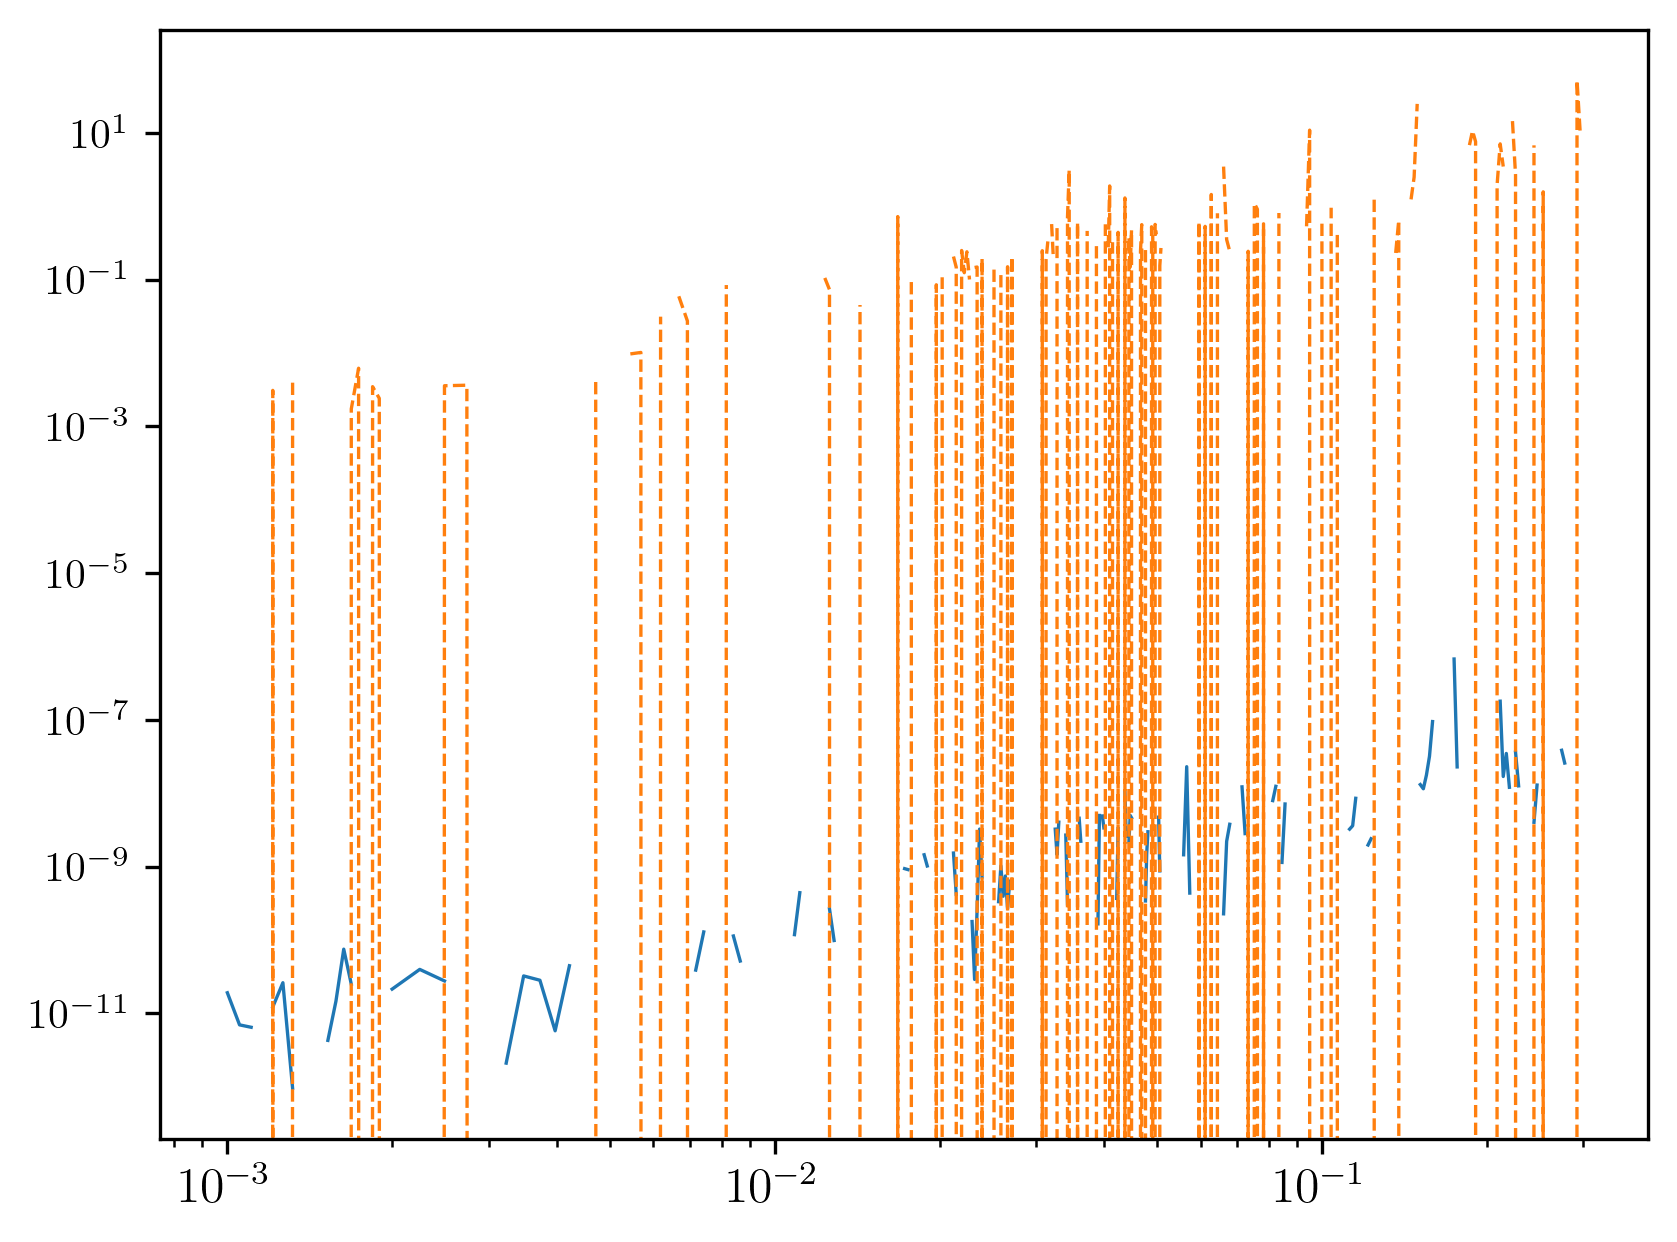

In [140]:
Fcov = FisherCov()
res = Fcov(full_AB_cov, v_fiducial, Ks)
plt.loglog(Ks, F_AB[:, 0, 0]**-0.5)
plt.plot(Ks, res[:, 0, 0]**-0.5, ls = "--")
plt.xscale("log")

In [141]:
is_pos_def(F_cross[3, :2, :2]), F_cross[3, :2, :2]

(Array(False, dtype=bool),
 Array([[2.6036036e+05, 4.9249438e+01],
        [4.9249438e+01, 9.3159617e-03]], dtype=float64))

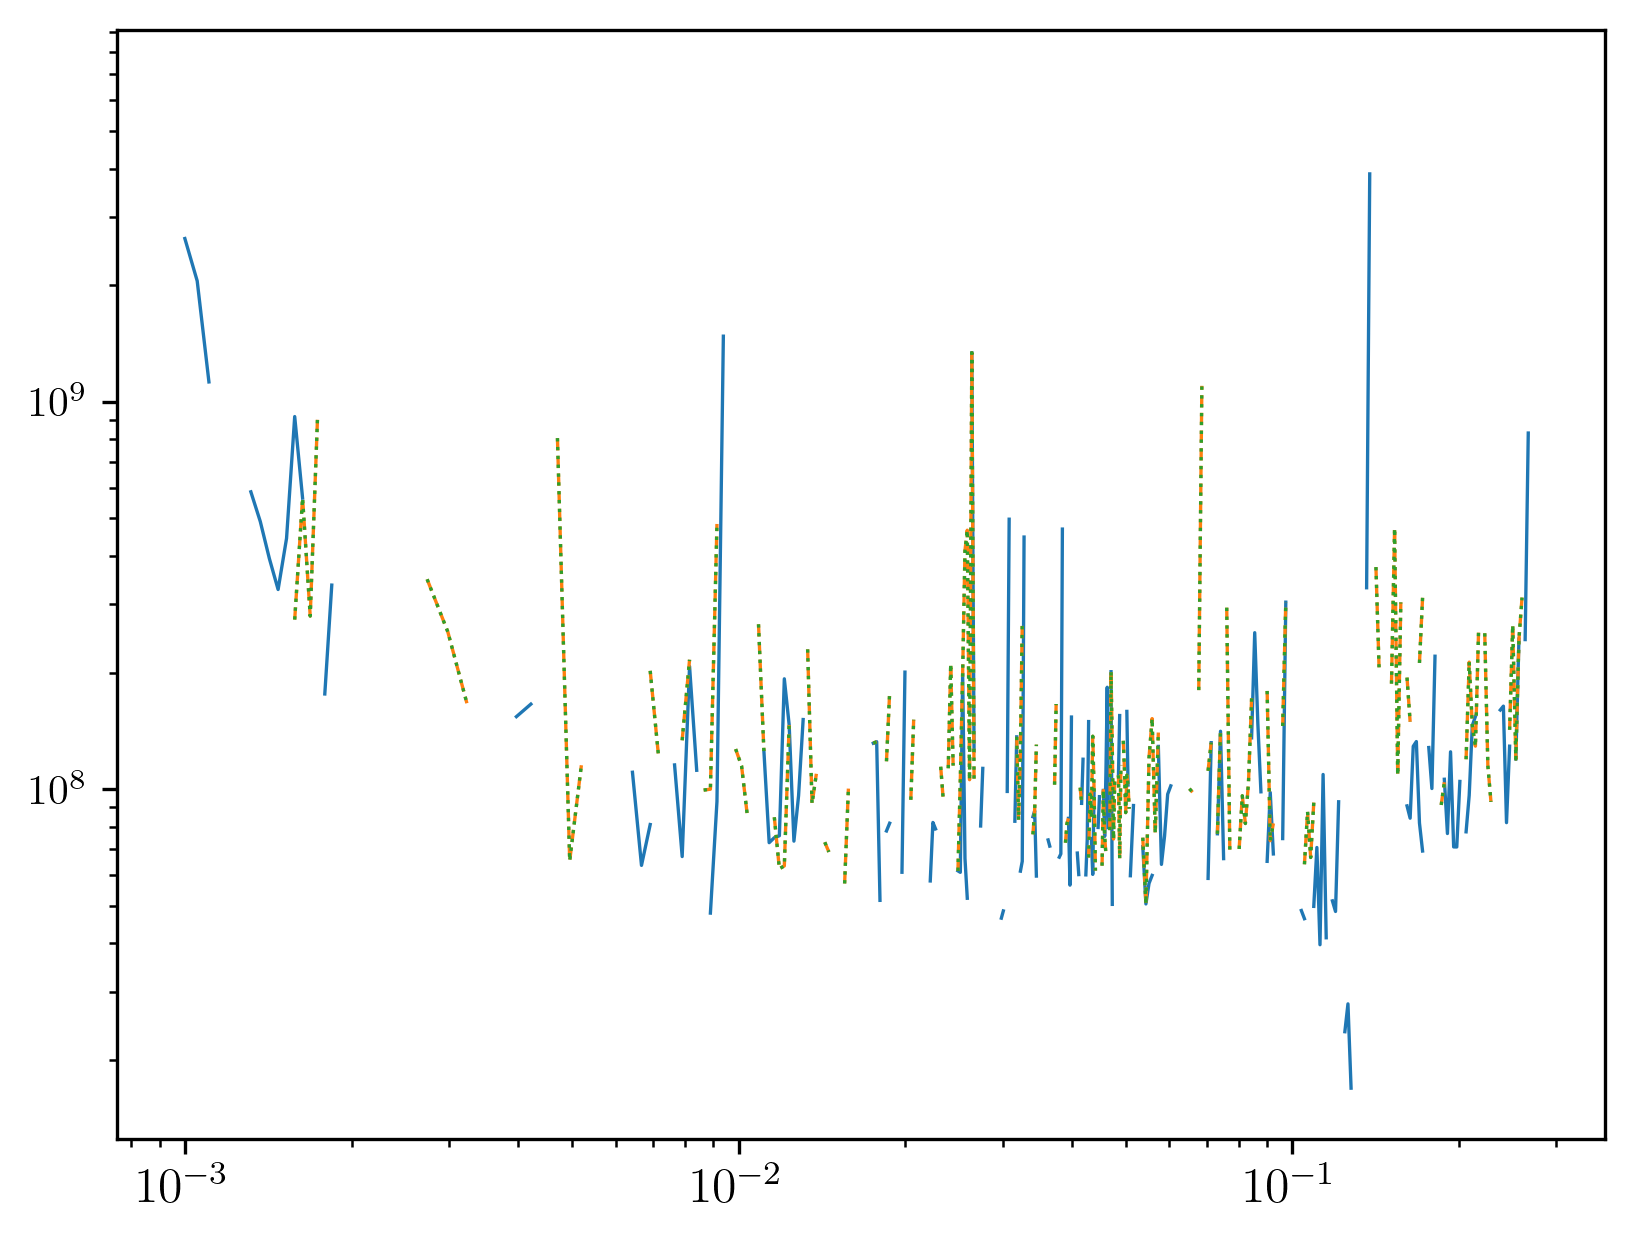

In [142]:
selected = [0, 1]

def inv_error(FF):
    return jnp.linalg.inv(FF[:, selected][:, :, selected])[:, index, index]**0.5
    #return FF[:, index, index]**-0.5


plt.loglog(Ks, inv_error(F_cross), label = "Cross with variance definition, A only")
plt.loglog(Ks, inv_error(F_cross_cov), label = "Cross with covariance definition, A only", ls = "--")

plt.loglog(Ks, inv_error(F_cross_cov), label = "Cross with covariance definition", ls = ":")


# Switching on and off the epsilon term

We are going to use the whole set of observables

In [15]:
gg = CAA(v_fiducial)
covgg = 2*gg**2
der_gg = plinf(Ks)*2*b1A
fggA = der_gg**2/covgg

gg = CBB(v_fiducial)
covgg = 2*gg**2
der_gg = plinf(Ks)*2*b1B
fggB = der_gg**2/covgg

<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_255116/3493435585.py:21: SyntaxWarning: invalid escape sequence '\e'
  labels = ["$\epsilon$", "$b_{1A}$", "$b_{1B}$", "$b_{2A}$", "$b_{2B}$"]


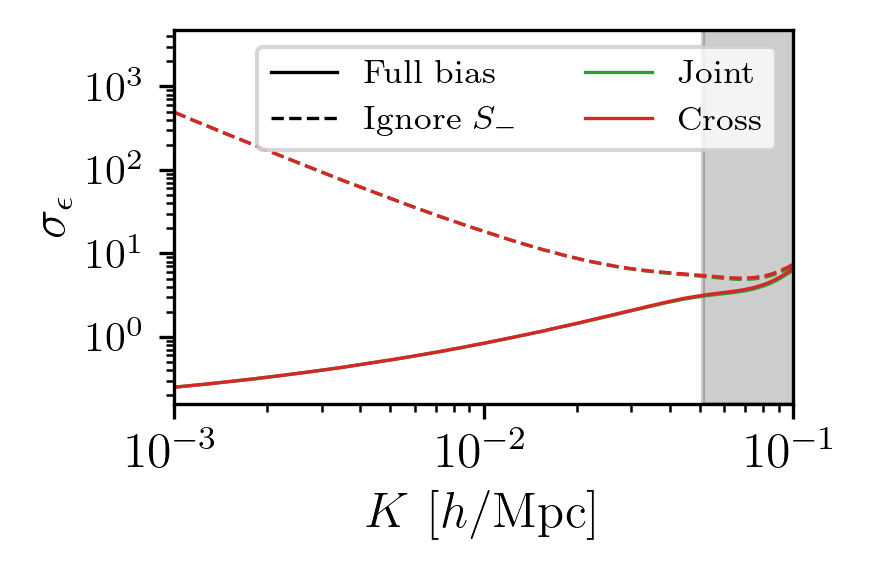

In [16]:
from matplotlib.lines import Line2D

asymm_shift = 1.
trispectrum_factor = 1.
bispectrum_factor = 1.
variance_factor = 1.
growth_eps = 0.
only_asymm_shift = 0.
shot_noise_A = 1/nbar_A
shot_noise_B = 1/nbar_B
shot_noise_AB = 0

key = "n"
key2 = None


indices = [0]#, 1, 2]
fig, axs = plt.subplots(1, len(indices), figsize=(3, 2), dpi=plot.DPI, facecolor='white')
if len(indices) == 1:
    axs = [axs]
labels = ["$\epsilon$", "$b_{1A}$", "$b_{1B}$", "$b_{2A}$", "$b_{2B}$"]

#fig.suptitle("Per mode error bars: including (dashed) or not (solid) asymm shift bias", fontsize = 4)

for index_case, asymm_shift in enumerate([0, 1]):
    
    CAA, CBB, CAR, CBR, CRR, CAB = get_functions(QR, key, key2 = key2, 
              shot_noise_A = shot_noise_A, shot_noise_B = shot_noise_B, shot_noise_AB = shot_noise_AB,
              variance_factor = variance_factor, bispectrum_factor = bispectrum_factor, 
              trispectrum_factor = trispectrum_factor, asymm_shift = asymm_shift, 
              only_asymm_shift = only_asymm_shift, growth_eps = growth_eps, keys = keys)

    CAAf, CARf, CRRf, CBBf, CBRf, CABf = get_functions_vA_vB(CAA, CAR, CRR, CBB, CBR, CAB)
    
    full_AB_cov = get_cov_with_AB(*get_functions_vA_vB(CAA, CAR, CRR, CBB, CBR, CAB))
    F_joint_AB = fisher.fisher_per_mode(v_fiducial, Ks, full_AB_cov)

    O_AB, Ovar_AB = get_Ofuncs_AB(CAAf, CBBf, CABf, CARf, CBRf, CRRf)
    F_cross_AB = fisher.fisher_per_mode_single_with_covariance(v_fiducial, Ks, O_AB, Ovar_AB)
    F_cross_AB = jnp.nan_to_num(F_cross_AB)

    for i, index in enumerate(indices):
        ax = axs[i]
        #ax.set_title(labels[i])
        ax.loglog(Ks, F_joint_AB[:, index, index]**-0.5, label = "Joint" if index_case == 1 else None, color = plot.COLORBLIND_PALETTE_2[2], ls = "--" if index_case == 0 else "-")
        ax.loglog(Ks, F_cross_AB[:, index, index]**-0.5, color = plot.COLORBLIND_PALETTE_2[3], label = "Cross-only" if index_case == 1 else None, ls = "--" if index_case == 0 else "-")
        ax.set_xlabel(r'$K \ [h/\mathrm{Mpc}]$', fontsize=12)
        ax.set_ylabel(r'$\sigma_\epsilon$', fontsize=12)
        ax.set_xlim(1e-3, 1e-1)
        #ax.set_ylim(1e-6)
        ax.axvspan(QR.kmin, QR.kmax, alpha=0.1, color = 'black')

legend_elements = [
                    Line2D([0], [0], color = 'black', ls = "-", label='Full bias'),
                    Line2D([0], [0], color = 'black', ls = "--", label='Ignore $S_{-}$'),
                    Line2D([0], [0], color = plot.COLORBLIND_PALETTE_2[2], label='Joint'),
                    Line2D([0], [0], color = plot.COLORBLIND_PALETTE_2[3], label='Cross')
                   ]

ax.legend(handles=legend_elements, loc='upper right', ncol = 2)
fig.tight_layout()
fig.savefig(f"/users/odarwish/long-modes/figures/fisher_per_mode_ignore_shift.pdf", dpi = 300, bbox_inches='tight')

## Let's try with just one single tracer A

In [17]:
factor_boosting = 1e-10

asymm_shift = 1.
trispectrum_factor = 1.
bispectrum_factor = 1.
variance_factor = 1#e-30
growth_eps = 0.
only_asymm_shift = 0.
shot_noise_A = 1/nbar_A*factor_boosting
shot_noise_B = 1/nbar_B*(1+factor_boosting)*factor_boosting
shot_noise_AB = 0

key = "n"
key2 = None

CAA, CBB, CAR, CBR, CRR, CAB = get_functions(QR, key, key2 = key2, 
              shot_noise_A = shot_noise_A, shot_noise_B = shot_noise_B, shot_noise_AB = shot_noise_AB,
              variance_factor = variance_factor, bispectrum_factor = bispectrum_factor, 
              trispectrum_factor = trispectrum_factor, asymm_shift = asymm_shift, 
              only_asymm_shift = only_asymm_shift, growth_eps = growth_eps, keys = keys)

In [18]:
cov_A_only = get_cov(CAAf, CARf, CRRf)
F_AA_only = fisher.fisher_per_mode(v_fiducial, Ks, cov_A_only)

cov_B_only = get_cov(CBBf, CBRf, CRRf)
F_BB_only = fisher.fisher_per_mode(v_fiducial, Ks, cov_B_only)

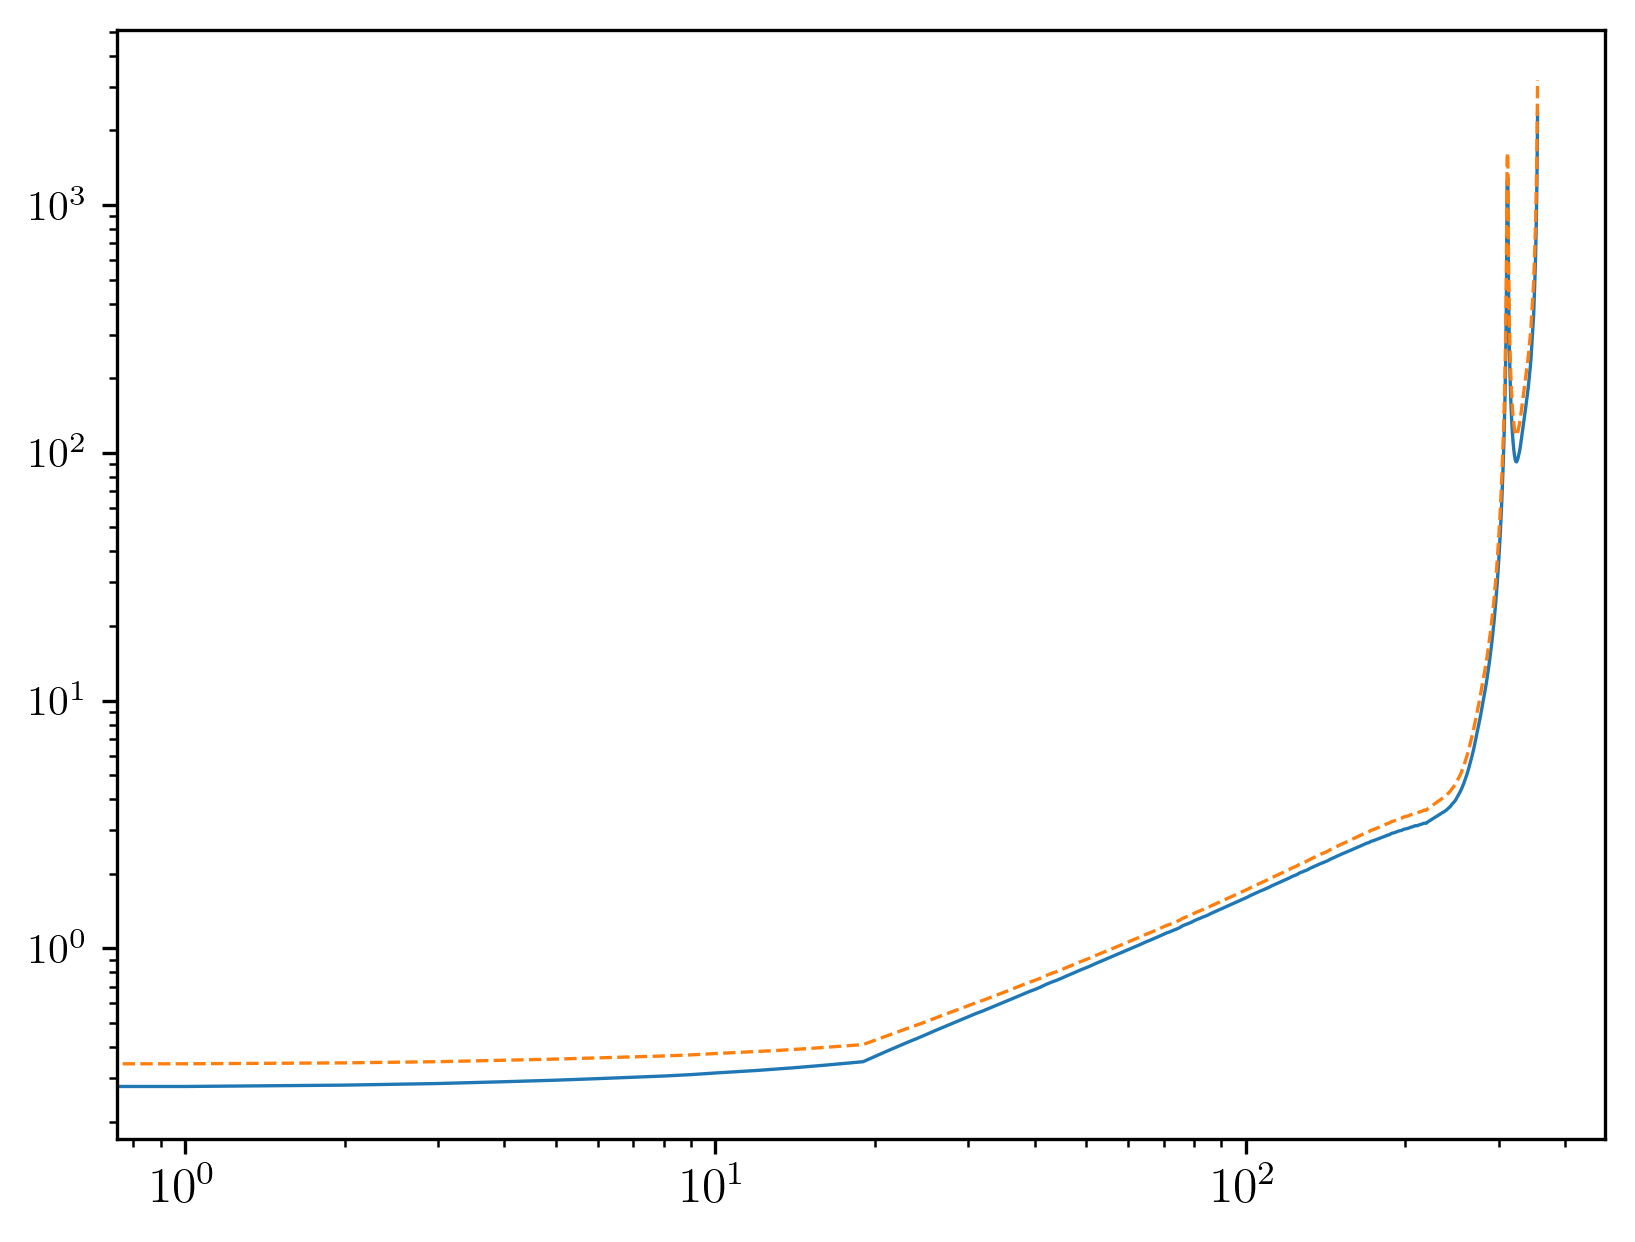

In [19]:
index = 0
plt.loglog(F_AA_only[:, index, index]**-0.5)
plt.loglog(F_BB_only[:, index, index]**-0.5, ls = "--")

# Integrated Fisher

In [81]:
from interpax import interp1d, Interpolator1D
from quadax import quadgk, simpson
import quadax

import jax.numpy as jnp
from jax import vmap

def integrate_upper_triangular(F, Ks):
    """
    Integrate over upper triangular indices and symmetrize result.
    
    Args:
        F: JAX array of shape (N, M, M) - symmetric matrix
        Ks: JAX array of shape (N,) - integration variable
    
    Returns:
        result: JAX array of shape (M, M) - symmetrized integration result
    """
    N, M, _ = F.shape
    
    # Create upper triangular indices
    i, j = jnp.triu_indices(M)
    
    # Extract upper triangular elements: shape (num_pairs, N)
    F_upper = F[:, i, j].T  # Transpose to get (num_pairs, N)
    
    # Vectorized integration over all upper triangular pairs
    #integrate_fn = lambda f_vals: quadax.simpson(y=Ks**2 * f_vals, x=Ks)
    integrate_fn = lambda f_vals: quadax.trapezoid(y=Ks**2 * f_vals, x=Ks)
    results = vmap(integrate_fn)(F_upper)
    
    # Create symmetric result matrix
    result = jnp.zeros((M, M))
    result = result.at[i, j].set(results)
    result = result.at[j, i].set(results)  # Symmetrize
    
    return result

def get_F_integrated_fast_new(K_array, F, k_min_analysis=0.01, k_max_analysis=0.05, V=1):
    """
    Fast vectorized version of get_F_integrated.
    Given a Fisher matrix per mode, integrates to give a function.
    Optimized version that vectorizes the integration over all parameter pairs.
    
    Args:
        K_array: Array of k values for interpolation
        F: Fisher matrix per mode (n_modes, n_params, n_params)
        k_min_analysis: Minimum k for integration
        k_max_analysis: Maximum k for integration
        V: Volume in Gpc^3 h^{-3}
    
    Returns:
        F_integrated: Integrated Fisher matrix (n_params, n_params)
    """
    V *= 1e9  # Convert to Mpc^3 h^{-3}

    #Ksdeep = jnp.linspace(k_min_analysis, k_max_analysis, 150)
    #Finterpolated = interp1d(Ksdeep, K_array, F)
    #F_integrated = jnp.trapezoid(Finterpolated*Ksdeep[:, None, None]**2, Ksdeep, axis=0)

    if False:
        Finterpolated = Interpolator1D(Ks, F)
        epsabs = epsrel = 1e-5 # by default jax uses 32 bit, higher accuracy requires going to 64 bit
        a, b = k_min_analysis, k_max_analysis
        F_integrated, info = quadgk(lambda K: Finterpolated(K)*K**2, [a, b], epsabs=epsabs, epsrel=epsrel)
    else:
        sel = (Ks >= k_min_analysis) & (Ks <= k_max_analysis)
        if True:
            F_integrated = integrate_upper_triangular(F[sel, :, :], Ks[sel])
        else:
            KK = Ks[sel]
            F_integrated = jnp.trapezoid(F[sel]*KK[:, None, None]**2, KK, axis=0)
        
    # Apply prefactor (factor of 2 from mu integration)
    prefactor = 2 * V / (2 * jnp.pi)**2
    F_integrated = F_integrated * prefactor

    return F_integrated

In [293]:
def cumulative_fisher(K_array, F, k_min_analysis, k_max_analysis, V):
    
    N, M, _ = F.shape
    
    # Create upper triangular indices
    i, j = jnp.triu_indices(M)

    sel = (K_array >= k_min_analysis) & (K_array <= k_max_analysis)
    F_sel = F[sel]
    K_sel = Ks[sel]
    
    # Extract upper triangular elements: shape (num_pairs, N)
    F_upper = F_sel[:, i, j].T  # Transpose to get (num_pairs, N)

    # Vectorized integration over all upper triangular pairs
    #integrate_fn = lambda f_vals: quadax.simpson(y=Ks**2 * f_vals, x=Ks)
    integrate_fn = lambda f_vals: quadax.cumulative_trapezoid(y = K_sel**2 * f_vals, x=K_sel,initial=0)
    results = vmap(integrate_fn)(F_upper)
    #F_sel = F_AB[sel]
    #K_sel = Ks[sel]
    #cumulative_F = quadax.cumulative_trapezoid(y = F_sel[:, 0, 0], x = K_sel, axis = 0)

    #print(results[1, 0], quadax.trapezoid(y = K_sel[1:]**2 * F_sel[1:, 0, 0], x=K_sel[1:]))
        
    # Create symmetric result matrix
    result = jnp.zeros((M, M, K_sel.size))
    result = result.at[i, j, :].set(results)
    result = result.at[j, i, :].set(results)  # Symmetrize
    
    result = result.T

    prefactor = 2 * V / (2 * jnp.pi)**2
    
    return K_sel, result*prefactor

In [294]:
def ger_errors_cumulative(fisher, selected, Kmin, Kmax, V):
    modes, F_int = cumulative_fisher(Ks, fisher[:, selected][:, :, selected], k_min_analysis = k_min_analysis, k_max_analysis = Kmax, V = V)
    #err_matrix = jnp.array([jnp.diag(F_)**-0.5 for F_ in F_int])
    #err_marginalized_matrix = jnp.array([jnp.diag(jnp.linalg.inv(F_))**0.5 for F_ in F_int])
    #return modes, err_matrix, err_marginalized_matrix
    err_matrix = jnp.diagonal(F_int, axis1 = 1, axis2 = 2)**-0.5
    err_marginalized_matrix = jnp.diagonal(jnp.linalg.inv(F_int), axis1 = 1, axis2 = 2)**0.5
    return modes, err_matrix, err_marginalized_matrix

In [295]:
selected = [0, 1, 2, 3, 4]

In [296]:
modes, F_int = cumulative_fisher(Ks, F_AB[:, selected][:, :, selected], k_min_analysis = k_min_analysis, k_max_analysis = Kmax, V = V)
modes, err, errm = ger_errors_cumulative(F_AB, selected, k_min_analysis, Kmax, V)

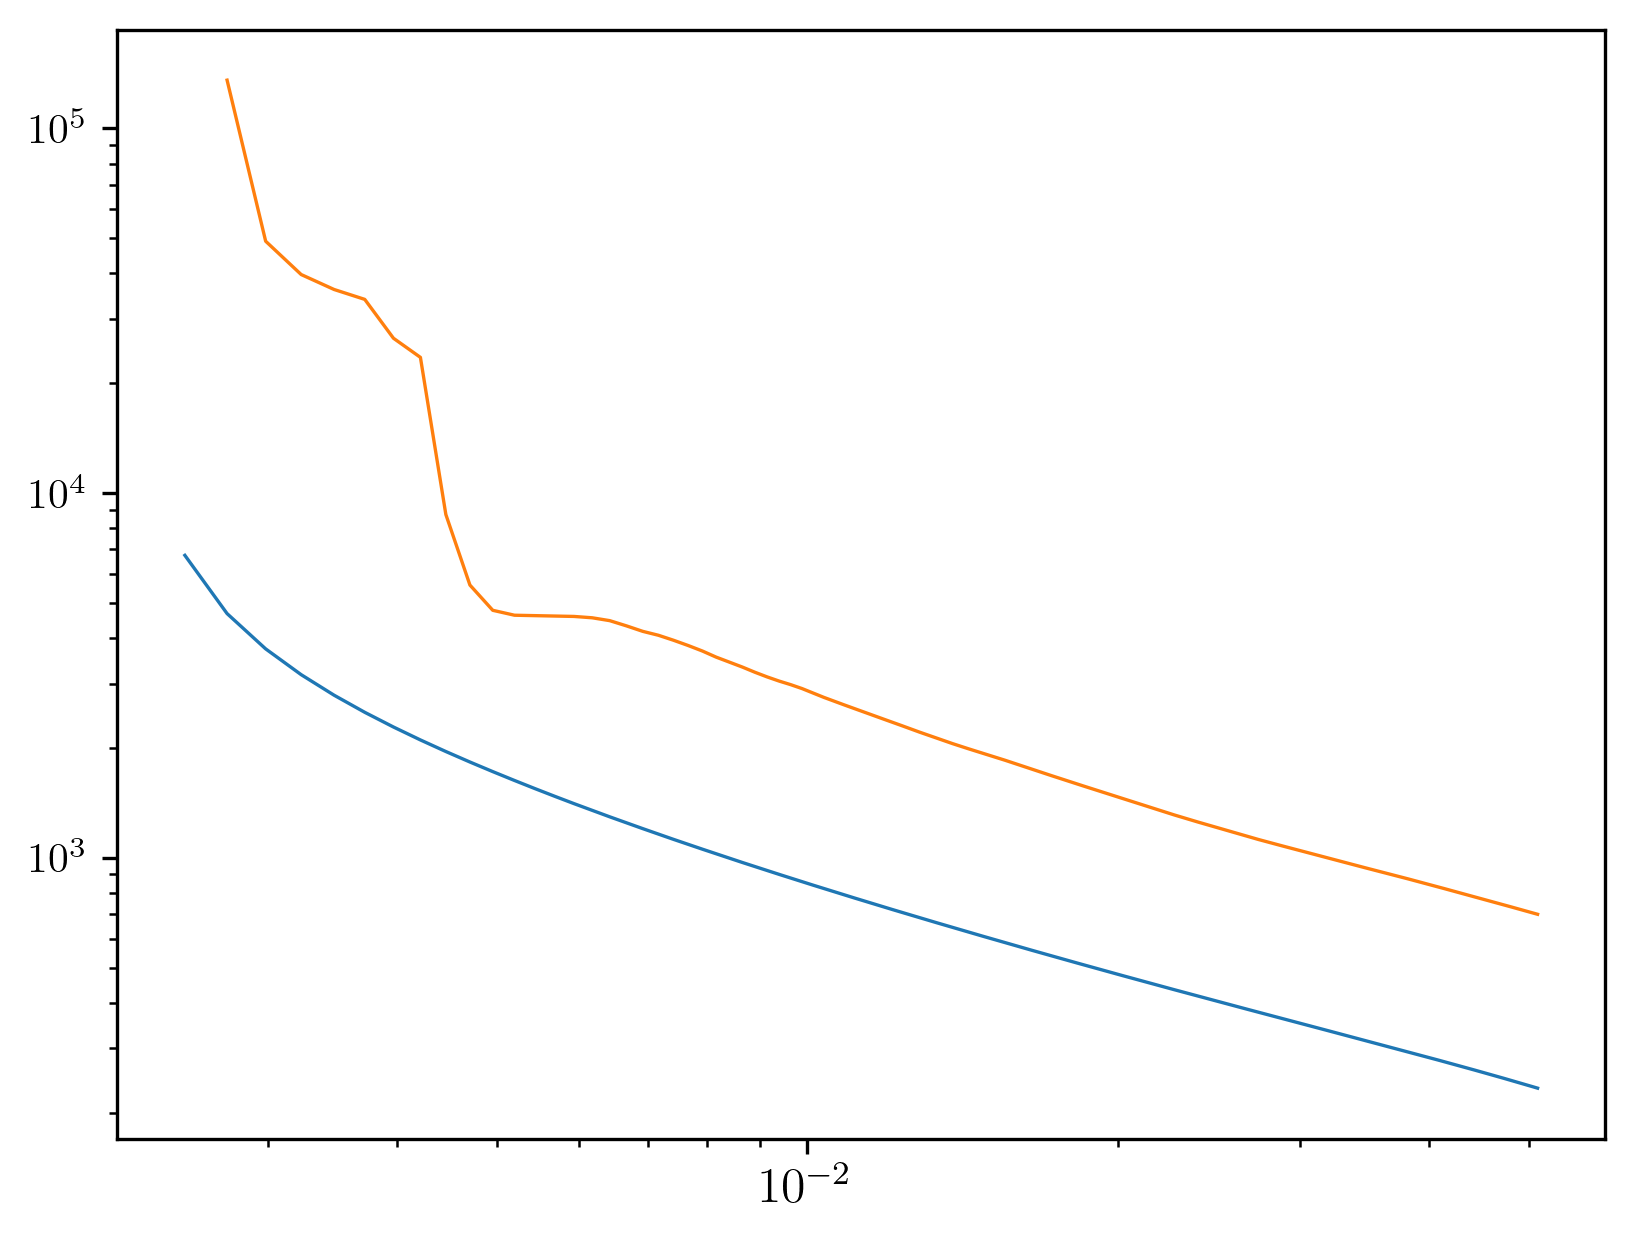

In [298]:
plt.loglog(modes, err[:, 0])
plt.loglog(modes, errm[:, 0])

In [85]:
def get_integrated_fisher(K_array, F, Kmin = 0.001, Kmax = 0.05, V = 1, Narr = 20, new = False):
    
    err_ms, err_us = [], []
    
    Kmaxarr = min(0.2, Kmax)
    modes = jnp.logspace(np.log10(Kmin), np.log10(Kmaxarr), Narr) if Narr > 1 else [Kmin]

    F_int = []
    for KK in modes:
        if new:
            F_integrated = get_F_integrated_fast_new(K_array, F, KK, Kmax, V = V)
        else:
            F_integrated = fisher.get_F_integrated_fast(K_array, F, KK, Kmax, V = V, N = 999)
        F_int.append(F_integrated)
        
    return modes, F_int

def ger_errors(fisher, selected, Kmin, Kmax, V, Narr = 50, new = True):
    modes, F_int = get_integrated_fisher(Ks, fisher[:, selected][:, :, selected], Kmin = Kmin, Kmax = Kmax, V = V, Narr = Narr, new = new)
    err_matrix = jnp.array([jnp.diag(F_)**-0.5 for F_ in F_int])
    err_marginalized_matrix = jnp.array([jnp.diag(jnp.linalg.inv(F_))**0.5 for F_ in F_int])
    return modes, err_matrix, err_marginalized_matrix


Kmax = 5.1e-2
h = 0.67
V = 30  #100*h**3 #in Gpc h^{-3}
V_MPC3 = V*1e9
k_min_analysis = 2*np.pi/V_MPC3**(1/3)
print(k_min_analysis)


v_fiducial = jnp.array([e*0., b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])
v_fiducial = jnp.array([1e-40, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])

0.002022116238530652


In [86]:

asymm_shift = 1.
trispectrum_factor = 1.
bispectrum_factor = 1.
variance_factor = 1
growth_eps = 0.
only_asymm_shift = 0.
shot_noise_A = 1/nbar_A
shot_noise_B = 1/nbar_B
shot_noise_AB = 0.

key = "n"
key2 = None

CAA, CBB, CAR, CBR, CRR, CAB = get_functions(QR, key, key2 = key2, 
                                              shot_noise_A = shot_noise_A, shot_noise_B = shot_noise_B, shot_noise_AB = shot_noise_AB,
                                              variance_factor = variance_factor, bispectrum_factor = bispectrum_factor, 
                                              trispectrum_factor = trispectrum_factor, asymm_shift = asymm_shift, 
                                              only_asymm_shift = only_asymm_shift, growth_eps = growth_eps, keys = keys)
########## Include also Growth estimator

key2 = "g"
_, _, CAR2, CBR2, CR2R2, _ = get_functions(QR, key2, key2 = None, 
              shot_noise_A = shot_noise_A, shot_noise_B = shot_noise_B, shot_noise_AB = shot_noise_AB,
              variance_factor = variance_factor, bispectrum_factor = bispectrum_factor, 
              trispectrum_factor = trispectrum_factor, asymm_shift = asymm_shift, 
              only_asymm_shift = only_asymm_shift, growth_eps = growth_eps, keys = keys)

key2 = "g"
CRR2 = get_functions(QR, key, key2 = key2, 
              shot_noise_A = shot_noise_A, shot_noise_B = shot_noise_B, shot_noise_AB = shot_noise_AB,
              variance_factor = variance_factor, bispectrum_factor = bispectrum_factor, 
              trispectrum_factor = trispectrum_factor, asymm_shift = asymm_shift, 
              only_asymm_shift = only_asymm_shift, growth_eps = growth_eps, keys = keys)

##########

CAAf, CARf, CRRf, CBBf, CBRf, CABf = get_functions_vA_vB(CAA, CAR, CRR, CBB, CBR, CAB)
_, CAR2f, CR2R2f, _, CBR2f, _ = get_functions_vA_vB(CAA, CAR2, CR2R2, CBB, CBR2, CAB)
CRR2f = CRR2


full_AB_cov = get_cov_with_AB(*get_functions_vA_vB(CAA, CAR, CRR, CBB, CBR, CAB))
F_joint_tr = fisher.fisher_per_mode(v_fiducial, Ks, full_AB_cov) #joint using trace expression

O_AB, Ovar_AB = get_Ofuncs_AB(CAAf, CBBf, CABf, CARf, CBRf, CRRf)
F_cross_cov = fisher.fisher_per_mode_single_with_covariance(v_fiducial, Ks, O_AB, Ovar_AB)
F_cross_cov = jnp.nan_to_num(F_cross_cov) #cross using cov expression

O_joint_cov, Ovar_joint_cov  = get_Ofuncs_AB_joint(CAAf, CBBf, CABf, CARf, CBRf, CRRf)
F_joint_cov = fisher.fisher_per_mode_single_with_covariance(v_fiducial, Ks, O_joint_cov, Ovar_joint_cov)
F_joint_cov = jnp.nan_to_num(F_joint_cov) #joint using cov expression


full_ABG_cov = get_cov_with_AB_R_R2(CAAf, CARf, CRRf, CBBf, CBRf, CABf, 
                         CAR2f, CBR2f, CRR2f, CR2R2f) 
F_growth_joint_tr = fisher.fisher_per_mode(v_fiducial, Ks, full_ABG_cov) #joint using trace expression, and include growth estimator

#####################

key = "n"
key2 = None

#setting asymm_shift to zero!
CAA, CBB, CAR, CBR, CRR, CAB = get_functions(QR, key, key2 = key2, 
                                              shot_noise_A = shot_noise_A, shot_noise_B = shot_noise_B, shot_noise_AB = shot_noise_AB,
                                              variance_factor = variance_factor, bispectrum_factor = bispectrum_factor, 
                                              trispectrum_factor = trispectrum_factor, asymm_shift = 0, 
                                              only_asymm_shift = only_asymm_shift, growth_eps = growth_eps, keys = keys)

full_AB_cov = get_cov_with_AB(*get_functions_vA_vB(CAA, CAR, CRR, CBB, CBR, CAB))
F_joint_tr_no_shift = fisher.fisher_per_mode(v_fiducial, Ks, full_AB_cov) #joint using trace expression


#####################

key = "n"
key2 = None

#setting Gaussian variance to zero!
CAA, CBB, CAR, CBR, CRR, CAB = get_functions(QR, key, key2 = key2, 
                                              shot_noise_A = shot_noise_A, shot_noise_B = shot_noise_B, shot_noise_AB = shot_noise_AB,
                                              variance_factor = 0., bispectrum_factor = bispectrum_factor, 
                                              trispectrum_factor = trispectrum_factor, asymm_shift = asymm_shift, 
                                              only_asymm_shift = only_asymm_shift, growth_eps = growth_eps, keys = keys)

full_AB_cov = get_cov_with_AB(*get_functions_vA_vB(CAA, CAR, CRR, CBB, CBR, CAB))
F_joint_tr_no_gauss_var = fisher.fisher_per_mode(v_fiducial, Ks, full_AB_cov) #joint using trace expression



CAA, CBB, CAR, CBR, CRR, CAB = get_functions(QR, key, key2 = key2, 
                                              shot_noise_A = shot_noise_A, shot_noise_B = shot_noise_B, shot_noise_AB = shot_noise_AB,
                                              variance_factor = 0., bispectrum_factor = bispectrum_factor, 
                                              trispectrum_factor = trispectrum_factor, asymm_shift = asymm_shift, 
                                              only_asymm_shift = only_asymm_shift, growth_eps = growth_eps, keys = keys)


CAAf, CARf, CRRf, CBBf, CBRf, CABf = get_functions_vA_vB(CAA, CAR, CRR, CBB, CBR, CAB)
O_AB, Ovar_AB = get_Ofuncs_AB(CAAf, CBBf, CABf, CARf, CBRf, CRRf)
F_cross_cov_no_gauss_var = fisher.fisher_per_mode_single_with_covariance(v_fiducial, Ks, O_AB, Ovar_AB)
F_cross_cov_no_gauss_var = jnp.nan_to_num(F_cross_cov_no_gauss_var) #cross using cov expression

In [87]:
#v_fiducial = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])
#selected = list(range(13))#[0, 1, 2, 3, 4, 5, 6]

new = True

selected = list(range(7))+[7, 8, 11, 12]
Narr = 70
modes, err_joint_tr, err_marg_joint_tr = ger_errors(F_joint_tr, selected, k_min_analysis, Kmax, V, Narr = Narr, new = new)
modes, err_cross_cov, err_marg_cross_cov = ger_errors(F_cross_cov, selected, k_min_analysis, Kmax, V, Narr = Narr, new = new)
modes, err_joint_cov, err_marg_joint_cov = ger_errors(F_joint_cov, selected, k_min_analysis, Kmax, V, Narr = Narr, new = new)
modes, err_growth_joint_tr, err_marg_growth_joint_tr = ger_errors(F_growth_joint_tr, selected, k_min_analysis, Kmax, V, Narr = Narr, new = new)
modes, err_joint_tr_no_shift, err_marg_joint_tr_no_shift = ger_errors(F_joint_tr_no_shift, selected, k_min_analysis, Kmax, V, Narr = Narr, new = new)
#modes, err_joint_tr_no_gauss_var, err_marg_joint_tr_no_gauss_var = ger_errors(F_joint_tr_no_gauss_var, selected, k_min_analysis, Kmax, V, Narr = Narr)
#modes, err_cross_cov_no_gauss_var, err_marg_cross_cov_no_gauss_var = ger_errors(F_cross_cov_no_gauss_var, selected, k_min_analysis, Kmax, V, Narr = Narr)

/tmp/ipykernel_255116/3446396745.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


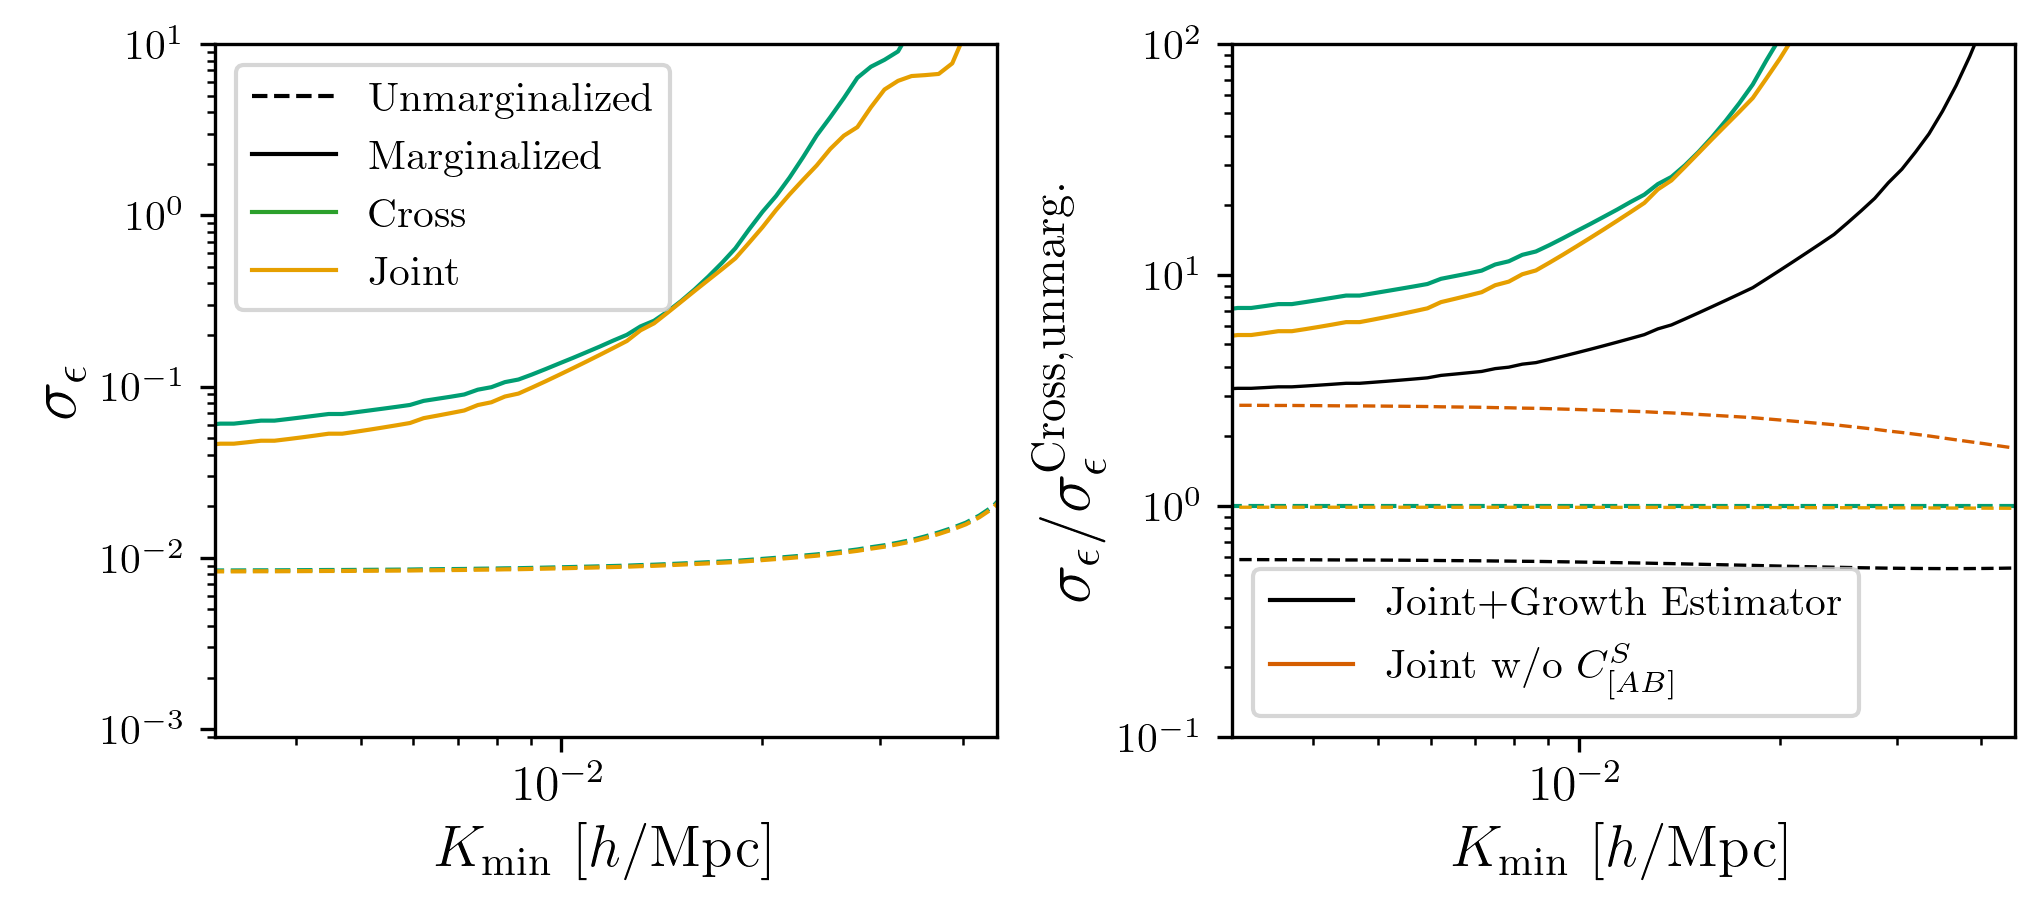

In [88]:
index = 0

from matplotlib.lines import Line2D

fig = plt.figure(figsize=(1.5*plot.FIG_WIDTH, 3), dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 2, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

color = lambda i: plot.COLORBLIND_PALETTE[i]
color2 = lambda i: plot.COLORBLIND_PALETTE_2[i]

s1, s2 = 2, 5
s3 = 7

base = 1

lw = 1.

ax.loglog(modes, err_cross_cov[:, index]/base, color = color(s1), ls = "--", lw=lw)
ax.loglog(modes, err_marg_cross_cov[:, index]/base, color = color(s1), lw=lw)


ax.loglog(modes, err_joint_tr[:, index]/base, color = color(s2), ls = "--", lw=lw)
ax.loglog(modes, err_marg_joint_tr[:, index]/base, color = color(s2), lw=lw)


#ax.set_ylim(ymin = 2e-3, ymax = 1)
ax.set_ylim(ymin = 9e-4, ymax = 10)

ax.set_xlim(k_min_analysis+0.001, 4.5e-2)
ax.set_xlabel(r'$K_{\mathrm{min}} \ [h/\mathrm{Mpc}]$', fontsize=14)
ax.set_ylabel(r'$\sigma_{\epsilon}$', fontsize=16)

legend_elements = [
    Line2D([0], [0], color = 'black', lw=lw, linestyle='--', label='Unmarginalized'),
    Line2D([0], [0], color = 'black', lw=lw, label='Marginalized'),
    Line2D([0], [0], color = color2(s1), lw=lw, label='Cross'),
    Line2D([0], [0], color = color(s2), lw=lw, label='Joint')
]

ax.legend(handles=legend_elements, loc='best', fontsize=10)


ax = fig.add_subplot(gs[0, 1])

base = err_cross_cov[:, index]


ax.loglog(modes, err_cross_cov[:, index]/base, color = color(s1), ls = "--", lw=lw)
ax.loglog(modes, err_marg_cross_cov[:, index]/base, color = color(s1), lw=lw)

ax.plot(modes, err_growth_joint_tr[:, index]/base, color = color(s3), ls = "--")
ax.plot(modes, err_marg_growth_joint_tr[:, index]/base, color = color(s3), ls = "-")

ax.plot(modes, err_joint_tr[:, index]/base, color = color(s2), ls = "--")
ax.loglog(modes, err_marg_joint_tr[:, index]/base, color = color(s2), lw=lw)

s4 = 1
ax.plot(modes, err_joint_tr_no_shift[:, index]/base, color = color(s4), ls = "--")
ax.plot(modes, err_marg_joint_tr_no_shift[:, index]/base, color = color(s4), ls = "-")


s5 = 4
#ax.plot(modes, err_joint_tr_no_gauss_var[:, index]/base, color = color2(s5), ls = "--", lw=lw)
#ax.plot(modes, err_cross_cov_no_gauss_var[:, index]/base, color = "cyan", ls = "--", lw=lw)


legend_elements = [
    Line2D([0], [0], color = color(s3), lw=lw, label='Joint+Growth Estimator'),
    Line2D([0], [0], color = color(s4), lw=lw, label='Joint w/o $C^{S}_{[AB]}$'),]
    #Line2D([0], [0], color = color2(s5), lw=lw, ls = "--", label='Joint w/o $V_{\mathcal{D}\mathcal{D}}$')]

ax.legend(handles=legend_elements, loc='best', fontsize=10)

ax.set_ylim(0.1, 1e2)
ax.set_xlim(k_min_analysis+0.001, 4.5e-2)
ax.set_xlabel(r'$K_{\mathrm{min}} \ [h/\mathrm{Mpc}]$', fontsize=14)
ax.set_ylabel(r'$\sigma_{\epsilon}/\sigma_{\epsilon}^{\mathrm{Cross,unmarg.}}$', fontsize=16)

plt.subplots_adjust(wspace=0.3)
fig.savefig(f"/users/odarwish/long-modes/figures/fisher_base.pdf", dpi = 300, bbox_inches='tight')
fig.tight_layout()
plt.show()
plt.close()

# Varying shot-noise

In [107]:
from qeep import fisher

def get_spectra_info(mainkey, QR, e, shot_noise_A, shot_noise_B, variance_factor, bispectrum_factor, trispectrum_factor, asymm_shift, only_asymm_shift, growth_eps):
    
    key2 = None

    keys = ["g", "s", "t", "ga", "sa", "ta"]

    CAA, CBB, CAR, CBR, CRR, CAB = get_functions(QR, key, key2 = key2, 
                                              shot_noise_A = shot_noise_A, shot_noise_B = shot_noise_B, shot_noise_AB = 0.,
                                              variance_factor = variance_factor, bispectrum_factor = bispectrum_factor, 
                                              trispectrum_factor = trispectrum_factor, asymm_shift = asymm_shift, 
                                              only_asymm_shift = only_asymm_shift, growth_eps = growth_eps, keys = keys)
    return CAA, CBB, CAR, CBR, CRR, CAB
    
def get_full_fisher(mainkey, QR, e, shot_noise_A, shot_noise_B, variance_factor, bispectrum_factor, trispectrum_factor, asymm_shift, only_asymm_shift, growth_eps, r2 = False):

    CAA, CBB, CAR, CBR, CRR, CAB = get_spectra_info(mainkey, QR, e, shot_noise_A, shot_noise_B, variance_factor, bispectrum_factor, trispectrum_factor, asymm_shift, only_asymm_shift, growth_eps)

    #plt.loglog(Ks, CRR(v_fiducial), label = shot_noise_A)
    
    CAAf, CARf, CRRf, CBBf, CBRf, CABf = get_functions_vA_vB(CAA, CAR, CRR, CBB, CBR, CAB)
    full_AB_cov = get_cov_with_AB(CAAf, CARf, CRRf, CBBf, CBRf, CABf)
    O_AB, Ovar_AB = get_Ofuncs_AB(CAAf, CBBf, CABf, CARf, CBRf, CRRf)
    
    F_joint_tr = fisher.fisher_per_mode(v_fiducial, Ks, full_AB_cov) #joint using trace expression
    F_cross_cov = fisher.fisher_per_mode_single_with_covariance(v_fiducial, Ks, O_AB, Ovar_AB)
    F_cross_cov = jnp.nan_to_num(F_cross_cov) #cross using cov expression
    
    if not r2:
        return F_cross_cov, F_joint_tr
    else:
        gr = CAR(vA)
        rr = CRR(vA)
        gg = CAA(vA)
        r2 = gr**2/(gg*rr)
        return F_cross_cov, F_joint_tr, r2

In [108]:
def generate_kmax_values(start=0.1, end=0.5, num_points=4):
    """Generate logarithmically spaced kmax values."""
    result = np.linspace(start, end, num_points)
    result = np.append(result, 0.15)
    result = np.unique(result)
    result = np.sort(result)
    return result

def generate_nbar_values(start=1e-5, end=1e2, num_points=10):
    """Generate logarithmically spaced nbar values."""
    return np.logspace(np.log10(start), np.log10(end), num_points)


nbar_values = generate_nbar_values(start=1e-5, end=1e2, num_points=10)
kmax_values = generate_kmax_values(start=0.1, end=0.5, num_points=4)

nbar_indices = np.arange(1, len(nbar_values))
kmax_indices = np.arange(1, len(kmax_values))

kmax_indices = kmax_indices[[1]]
nbar_indices = nbar_indices#[:5]

In [48]:
k_min_analysis = 0.003

from copy import deepcopy

selected = list(range(7))#+[7, 8, 11, 12]
Narr = 1

out_results = {}
nbars = []

conf_vary_kmax_indices = list(range(25, 31))
nbars_kmax = []

marker_sizes = np.linspace(50, 100, len(kmax_indices))

conf_ok = []
marker_size = []
for i in nbar_indices:
    for jind, j in enumerate(kmax_indices):
    
        configuration_i = f'../../configs/abacus/desi_nbars/config_desi_base_{i}_{j}.yaml'
    
        with open(configuration_i, 'r') as f:
            config_i = yaml.safe_load(f)
    
        name = config_i["name"]
        path = f"../../results/{name}/"
        #path = f"/users/odarwish/results/desi_base_asymm/"
        
        try:
            QR = qres.QEResults(config_i, relative_path = "../")
        except:
            print(i, j, "not found")
            continue
    
        conf_ok.append((i,j))
        marker_size.append(marker_sizes[jind])
        nbars.append(3*config_i["number_density"]["nbar_A"])
        
        configuration_base_i = {"mainkey": "n",
                              "QR": QR,
                              "e": 1e-10,
                              "shot_noise_A": 5000, #1/config_i["number_density"]["nbar_A"], 
                              "shot_noise_B": 5000, #1/config_i["number_density"]["nbar_B"], 
                              "variance_factor": 1, 
                              "bispectrum_factor": 1, 
                              "trispectrum_factor": 1, 
                              "asymm_shift": 1., #include asymm shift term or not. If 0, use only G, T asymm
                              "only_asymm_shift": 0., #only include asymm shift term or not, If 1, use only S asymm
                              "growth_eps": 0., #enhanced growth for galaxy clustering
                             }
    
        F_cross, F_joint = get_full_fisher(**configuration_base_i)
        modes, err_matrix, err_marginalized_matrix = ger_errors(F_joint, selected, k_min_analysis, Kmax, V, Narr = Narr)
        modes, err_matrix_cross, err_marginalized_matrix_cross = ger_errors(F_cross, selected, k_min_analysis, Kmax, V, Narr = Narr)
        
        out_results[(i, j)] = {"modes": modes, "err_matrix": err_matrix, "err_marginalized_matrix": err_marginalized_matrix, "err_matrix_cross": err_matrix_cross, "err_marginalized_matrix_cross": err_marginalized_matrix_cross}
        out_results[(i, j)]["F_joint"] = F_joint
        out_results[(i, j)]["F_cross"] = F_cross
    
        print("Done", (i, j))
#plt.legend()
#plt.show()
        

Done (1, 2)
Done (2, 2)
Done (3, 2)
Done (4, 2)
Done (5, 2)
Done (6, 2)
Done (7, 2)
Done (8, 2)
Done (9, 2)


In [49]:
nbars = np.array(nbars)

keys = tuple(['modes', 'err_matrix', 'err_marginalized_matrix', 'err_matrix_cross', 'err_marginalized_matrix_cross'])

index = 0

argmin_nbar = np.argmin(abs(np.unique(nbars)-5e-4))
#then, for 0.15 h/Mpc is 
argmin_kmax = 1

#base_nbar_index = conf_ok[conf_ok.index((argmin_nbar+1, argmin_kmax+1))]
base_nbar_index = conf_ok[0]

results = out_results[base_nbar_index]
modes, err_matrix, err_marginalized_matrix, err_matrix_cross, err_marginalized_matrix_cross = [results[k] for k in keys]
base = err_matrix_cross[:, index]

k = 'err_matrix_cross'
errors_noise_cross_nbar = np.array([out_results[f][k][:, index]/base for f in conf_ok])
k = 'err_marginalized_matrix_cross'
errors_marginalized_noise_cross_nbar = np.array([out_results[f][k][:, index]/base for f in conf_ok])

k = 'err_matrix'
errors_noise_joint_nbar = np.array([out_results[f][k][:, index]/base for f in conf_ok])
k = 'err_marginalized_matrix'
errors_marginalized_noise_joint_nbar = np.array([out_results[f][k][:, index]/base for f in conf_ok])

/tmp/ipykernel_96769/1162760957.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


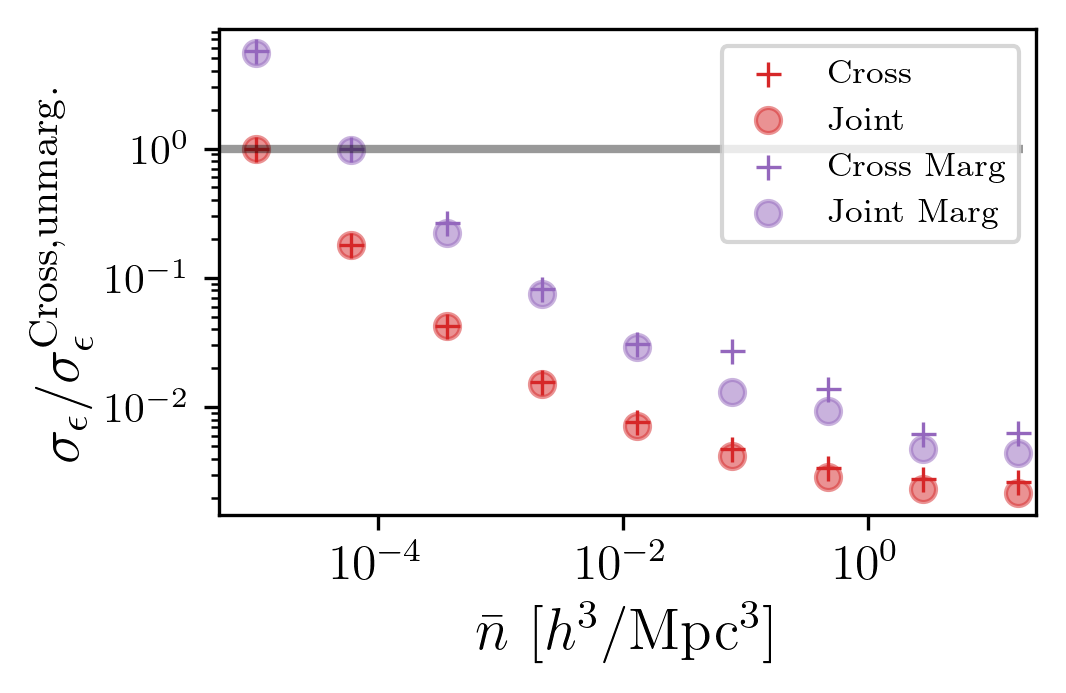

In [50]:
import matplotlib.cm as cm

index = 0

#nbar_1 = nbars[argmin] #
#nbar_2 = 1e-3 #
#nbar_3 = 0.33*nbar_1

from matplotlib.lines import Line2D

fig = plt.figure(figsize=plot.size, dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

color = lambda i: plot.COLORBLIND_PALETTE_2[i]

#ax.vlines(nbar_1, 1e-7, 2e3, color = color(6), ls = "--", lw = 2, alpha = 0.3)
#ax.vlines(nbar_2, 1e-7, 2e3, color = color(7), ls = "--", lw = 2, alpha = 0.3)
#ax.vlines(nbar_3, 1e-7, 2e3, color = color(7), ls = "--", lw = 2, alpha = 0.3)

n_kmax_points = len(kmax_indices)
colors_kmax = cm.viridis(np.linspace(0.2, 0.8, n_kmax_points))

i = 3
ax.scatter(nbars, errors_noise_cross_nbar, label = "Cross", color = color(i), marker = "+")#, s = marker_size)
ax.scatter(nbars, errors_noise_joint_nbar, label = "Joint", color = color(i), alpha = 0.5)#, s = marker_size)

i = 4
ax.scatter(nbars, errors_marginalized_noise_cross_nbar, label = "Cross Marg", color = color(i), marker = "+")
ax.scatter(nbars, errors_marginalized_noise_joint_nbar, label = "Joint Marg", color = color(i), alpha = 0.5)

#ax.scatter(nbars_kmax, errors_marginalized_noise_joint_nbar_kmax, label = "Joint Marg Increasing $k_{\mathrm{max,rec}}$", color = color(5), alpha = 0.5)

  # or use cm.plasma, cm.coolwarm
#for i, (x, y) in enumerate(zip(nbars_kmax, errors_marginalized_noise_joint_nbar_kmax)):
#    ax.scatter(x, y, color=colors_kmax[i], alpha=0.7)

#marker_sizes = np.linspace(50, 100, len(nbars_kmax))  # sizes increase with kmax
#ax.scatter(nbars_kmax, errors_marginalized_noise_joint_nbar_kmax, 
#           s=marker_sizes, color=color(i), alpha=0.5)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylabel(r'$\sigma_{\epsilon}/\sigma_{\epsilon}^{\mathrm{Cross,unmarg.}}$', fontsize=14)
ax.set_xlabel(r'$\bar{n}\ [h^3\mathrm{/Mpc^3]}$', fontsize=14)

ax.legend(fontsize = 8)

ax.set_xlim(nbars.min()*(1-0.5), nbars.max()*(1+0.4))
ax.hlines(1, nbars.min()*(1-0.5), nbars.max()*(1+0.1), color = "black", lw = 2, alpha = 0.4)
#ax.set_xlim(5e-6, 2)
#ax.set_ylim(1e-5, 1e3)

plt.subplots_adjust(wspace=0.3)
fig.savefig(f"/users/odarwish/long-modes/figures/fisher_varying_nbar.pdf", dpi = 300, bbox_inches='tight')
fig.tight_layout()
plt.show()
plt.close()

## Comparing analytical with numerical results

In [67]:
def Fanalytical(efid, CAA, CAR, CRR, corr_coeff_factor = 1.):
    #this function can be generalized by just passing CAA, CAR, CRR in function of one var
    
    CAA_ = lambda e: CAA(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
    CAR_ = lambda e: CAR(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
    CRR_ = lambda e: CRR(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
    
    der_gg = jax.jacfwd(CAA_)(efid)
    gg = CAA_(efid)
    fgg = der_gg/gg
    
    der_gr = jax.jacfwd(CAR_)(efid)
    gr = CAR_(efid)
    fgr = der_gr/gr
    
    der_rr = jax.jacfwd(CRR_)(efid)
    rr = CRR_(efid)
    frr = der_rr/rr

    rc2 = gr**2/(gg*rr)*corr_coeff_factor

    A = fgg-2*rc2*fgr
    A = A**2
    B = 2*rc2*(1-rc2)*fgr**2
    C = 2*rc2*frr*(fgg-2*fgr)
    D = frr**2
    return (A+B+C+D)*1/2*1/(1-rc2)**2

In [68]:
mainkey = "n"

biases_dict = config["bias"]
number_density = config["number_density"]

nbar_A = number_density["nbar_A"]
nbar_B = number_density["nbar_B"]

b1A = biases_dict["b10_A"]
b1B = biases_dict["b10_B"]
e = 1e-3

b2A, b2B = -0.3, -0.3
bs2A, bs2B = biases.bs2_coev(b1A), biases.bs2_coev(b1B)
bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = 2, 1, 2, 1, 2, 1

vA = jnp.array([e*0., b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])  #fiducial point

QR = qres.QEResults(config, relative_path="../.")
responses_dict = QR.get_out_normalization_AB()
responses = qres.get_normalization_array(mainkey, ["g", "s", "t", "ga", "sa", "ta"], Ks, responses_dict)

keys = ["g", "s", "t", "ga", "sa", "ta"]

In [69]:
from qeep import fisher

shot_noise = 0.
variance_factor = 0.
bispectrum_factor = 0.
trispectrum_factor = 0.
asymm_shift = 1.
only_asymm_shift = 0.
growth_eps = 0.

vfid = None
fiducial_auto = False
fiducial_cross = False
fiducial_power = False

asymm_shift, only_asymm_shift = 1., 0.
bias_temp_function = lambda e: get_tot_bias(get_v(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])), QR.get_get_norm()(mainkey), responses, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)

In [73]:
CAA, CAR, CRR_with_var = get_functions_vA_only(*get_functions(
        QR,
        mainkey,
        shot_noise_A=shot_noise,
        variance_factor=1e-10,
        bispectrum_factor=bispectrum_factor,
        trispectrum_factor=trispectrum_factor,
        asymm_shift=asymm_shift,
        only_asymm_shift=only_asymm_shift,
        growth_eps=growth_eps,
    ))
    
O, Ovar = get_Ofuncs(CAA, CAR, CRR_with_var)

TypeError: get_functions_vA_only() takes 3 positional arguments but 6 were given

In [14]:
index = 0
e = 0.
derivative = jax.jacfwd(bias_temp_function)(e)
FF = 0.5*(derivative/bias_temp_function(e))**2
err_cross_analytical = FF**-0.5 #analytical cross-error
############
O, Ovar = get_Ofuncs(CAA, CAR, CRR_with_var)
F_cross = fisher.fisher_per_mode_single(vA, Ks, O, Ovar)
F_cross = jnp.nan_to_num(F_cross)[:, index, index]
err_cross_numerical = F_cross**-0.5 #numerical cross-error
############
FF_joint = Fanalytical(0., CAA, CAR, CRR_with_var)
err_joint_analytical = FF_joint**-0.5 #analytical joint-error
############
cov = get_cov(CAA, CAR, CRR_with_var)
F_joint = fisher.fisher_per_mode(vA, Ks, cov)[:, index, index]
err_joint_numerical = (F_joint**-0.5)
############ ALTERNATIVE NUMERICAL
cov_function = get_cov(CAA, CAR, CRR_with_var)
covf = lambda e: cov_function(Ks, jnp.array([e[0], b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
covariance = covf(jnp.array([0.]))
der_covariance = jax.jacfwd(covf)(jnp.array([0.]))
inv_covariance = jnp.linalg.inv(covariance)
inv_covariance = jnp.nan_to_num(inv_covariance, posinf = 0.)
FF_joint_code = jnp.einsum('kij,kjla,klm, kmib ->kab', inv_covariance, der_covariance, inv_covariance, der_covariance)*0.5
err_joint_numerical_alt = FF_joint_code[:, index, index]**-0.5 #0 index is e

############
FF_joint = Fanalytical(0., CAA, CAR, CRR_with_var, corr_coeff_factor = 0.)
err_joint_analytical_indep = FF_joint**-0.5 #analytical joint-error, but independent, cross-corr coeff r = 0

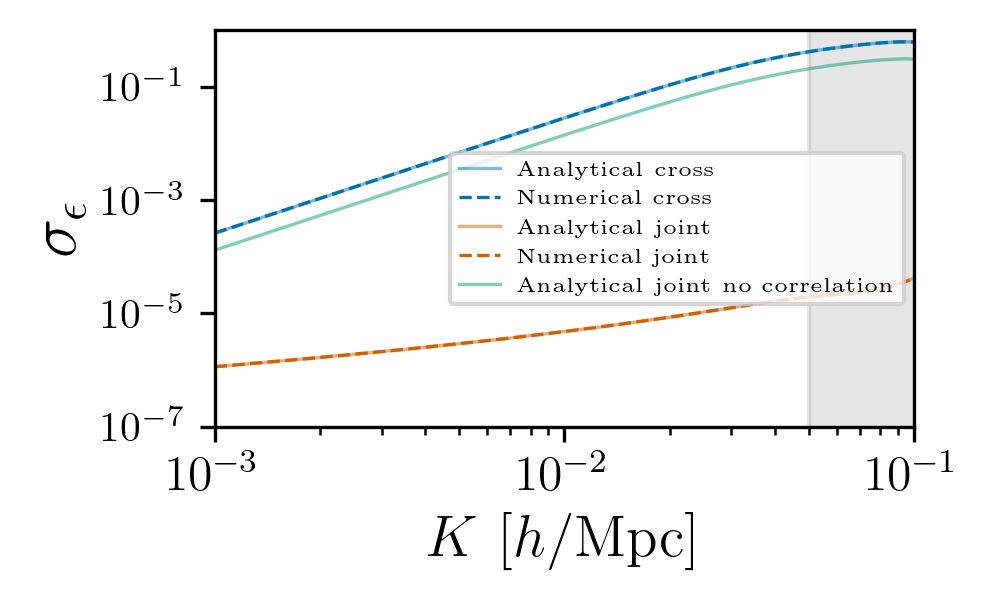

In [18]:
from matplotlib.lines import Line2D

fig = plt.figure(figsize=plot.size, dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 1, figure=fig)#, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

ax.loglog(Ks, err_cross_analytical, label = "Analytical cross", alpha = 0.5, color = plot.COLORBLIND_PALETTE[0])
ax.loglog(Ks, err_cross_numerical, label = "Numerical cross", ls = "--", color = plot.COLORBLIND_PALETTE[0])

ax.loglog(Ks, err_joint_analytical, label = "Analytical joint", alpha = 0.5, color = plot.COLORBLIND_PALETTE[1])
ax.loglog(Ks, err_joint_numerical, label = "Numerical joint", ls = "--", color = plot.COLORBLIND_PALETTE[1])

ax.loglog(Ks, err_joint_analytical_indep, label = "Analytical joint no correlation", alpha = 0.5, color = plot.COLORBLIND_PALETTE[2])

ax.fill_betweenx([0, 1], 5e-2, 0.15, color = "black", alpha = 0.1)

ax.legend(fontsize = 5, loc = "best")
ax.set_xlim(1e-3, 1e-1)
ax.set_ylim(1e-7, 1)
ax.set_xlabel(r'$K \ [h/\mathrm{Mpc}]$', fontsize=14)
ax.set_ylabel(r'$\sigma_{\epsilon}$', fontsize=16)

fig.savefig(f"/users/odarwish/long-modes/figures/fisher_analytical.pdf", dpi = 300, bbox_inches='tight')
fig.tight_layout()
plt.show()
plt.close()

## Full exploration

In [19]:
from qeep import fisher

vA = jnp.array([0*e, b1A, b2A, bs2A, bGXA*0, bGXB*0, bSXA*0, bSXB*0, bTXA*0, bTXB*0]) #fiducial point

vA = jnp.array([1e-9, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]) #fiducial point


mainkey = mainkey
QR = QR

shot_noise = 0.
variance_factor = 1
bispectrum_factor = 0.
trispectrum_factor = 0.
asymm_shift = 1.
only_asymm_shift = 0.
growth_eps = 0.

vfid = None
fiducial_auto = False
fiducial_cross = False
fiducial_power = False

<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_41404/3707633185.py:3: SyntaxWarning: invalid escape sequence '\e'
  labels = ["$\epsilon$", "$b_1$", "$b_2$"]


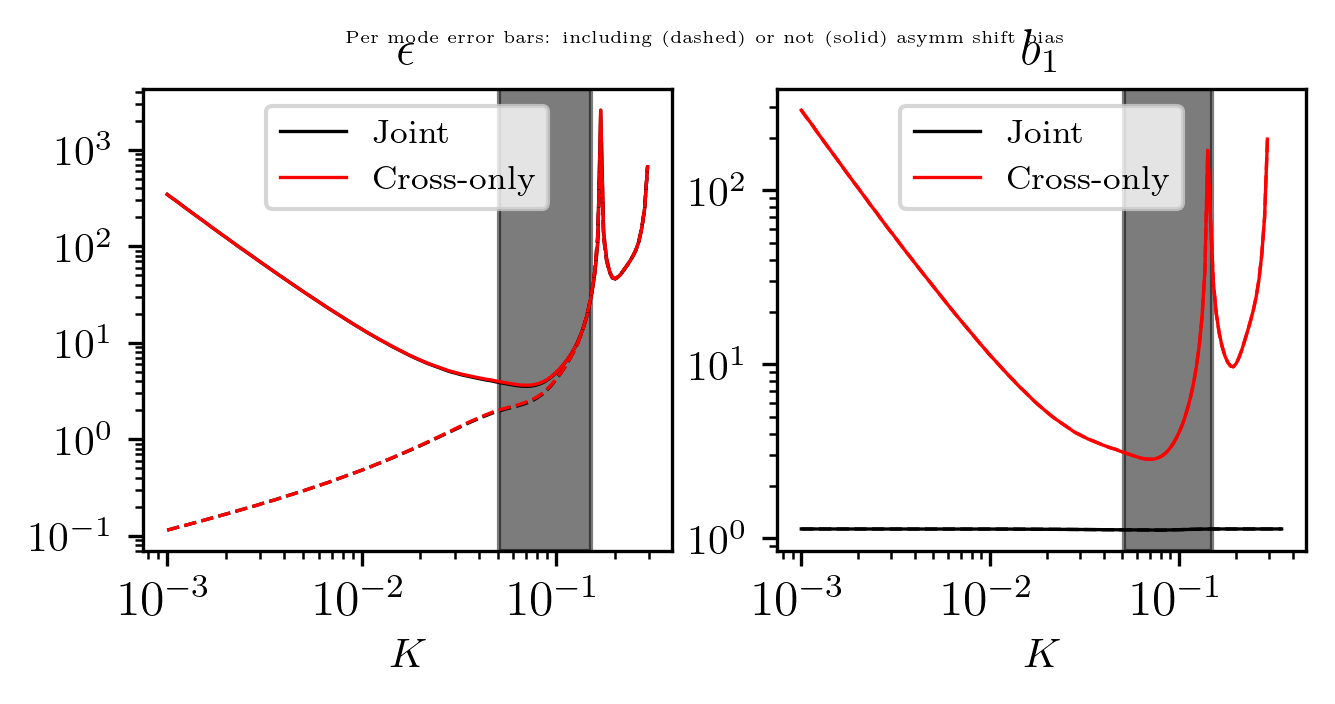

In [20]:
indices = [0, 1]
fig, axs = plt.subplots(1, len(indices), figsize=(5, 2), dpi=plot.DPI, facecolor='white')
labels = ["$\epsilon$", "$b_1$", "$b_2$"]

fig.suptitle("Per mode error bars: including (dashed) or not (solid) asymm shift bias", fontsize = 4)

for index_case, asymm_shift in enumerate([0, 1]):
    
    CAA, CAR, CRR = get_functions_vA_only(*get_functions(
        mainkey,
        QR,
        shot_noise=shot_noise,
        variance_factor=variance_factor,
        bispectrum_factor=bispectrum_factor,
        trispectrum_factor=trispectrum_factor,
        asymm_shift=asymm_shift,
        only_asymm_shift=only_asymm_shift,
        growth_eps=growth_eps,
        vfid=vfid,
        fiducial_auto=fiducial_auto,
        fiducial_cross=fiducial_cross,
        fiducial_power=fiducial_power
    ))
    
    cov = get_cov(CAA, CAR, CRR)
    O, Ovar = get_Ofuncs(CAA, CAR, CRR)
    
    F_single = fisher.fisher_per_mode_single(vA, Ks, O, Ovar)
    F_single = jnp.nan_to_num(F_single)
    
    F = fisher.fisher_per_mode(vA, Ks, cov)


    for i, index in enumerate(indices):
        ax = axs[i]
        ax.set_title(labels[i])
        ax.loglog(Ks, F[:, index, index]**-0.5, label = "Joint" if index_case == 0 else None, color = "black", ls = "-" if index_case == 0 else "--")
        ax.loglog(Ks, F_single[:, index, index]**-0.5, color = "red", label = "Cross-only" if index_case == 0 else None, ls = "-" if index_case == 0 else "--")
        ax.set_xlabel("$K$")
        #ax.set_xlim(1e-3, 1e-1)
        #ax.set_ylim(1e-6)
        ax.axvspan(QR.kmin, QR.kmax, alpha=0.3, color = 'black')
        ax.legend()
#fig.tight_layout()

## Paper results

In [21]:
def get_integrated_fisher(K_array, F, Kmin = 0.001, Kmax = 0.05, V = 1, Narr = 20):
    
    err_ms, err_us = [], []
    
    Kmaxarr = min(0.2, Kmax)
    modes = jnp.logspace(np.log10(Kmin), np.log10(Kmaxarr), Narr) if Narr > 1 else [Kmin]

    F_int = []
    for KK in modes:
        F_int.append(fisher.get_F_integrated_fast(K_array, F, KK, Kmax, V = V, N = 999))
        
    return modes, F_int

In [77]:
Kmax = 5e-2
def ger_errors(fisher, selected, Kmin, Kmax, V, Narr = 50, return_Fint = False):
    modes, F_int = get_integrated_fisher(Ks, fisher[:, selected][:, :, selected], Kmin = Kmin, Kmax = Kmax, V = V, Narr = Narr)
    err_matrix = jnp.array([jnp.diag(F_)**-0.5 for F_ in F_int])
    err_marginalized_matrix = jnp.array([jnp.diag(jnp.linalg.inv(F_))**0.5 for F_ in F_int])
    if not return_Fint:
        return modes, err_matrix, err_marginalized_matrix
    else:
        return modes, err_matrix, err_marginalized_matrix, F_int

In [23]:
from qeep import fisher

#vA = jnp.array([0*e, b1A, b2A, bs2A, bGXA*0, bGXB*0, bSXA*0, bSXB*0, bTXA*0, bTXB*0]) #fiducial point

def get_spectra_info(mainkey, QR, e, shot_noise, variance_factor, bispectrum_factor, trispectrum_factor, asymm_shift, only_asymm_shift, growth_eps):
    
    vA = jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]) #fiducial point
        
    vfid = None
    fiducial_auto = False
    fiducial_cross = False
    fiducial_power = False
        
    CAA, CAR, CRR = get_functions_vA_only(*get_functions(
            mainkey,
            QR,
            shot_noise=shot_noise,
            variance_factor=variance_factor,
            bispectrum_factor=bispectrum_factor,
            trispectrum_factor=trispectrum_factor,
            asymm_shift=asymm_shift,
            only_asymm_shift=only_asymm_shift,
            growth_eps=growth_eps,
            vfid=vfid,
            fiducial_auto=fiducial_auto,
            fiducial_cross=fiducial_cross,
            fiducial_power=fiducial_power
        ))
        

    return vA, CAA, CAR, CRR
    
def get_full_fisher(mainkey, QR, e, shot_noise, variance_factor, bispectrum_factor, trispectrum_factor, asymm_shift, only_asymm_shift, growth_eps, r2 = False):
    
    vA, cov, O, Ovar = get_spectra_info(mainkey, QR, e, shot_noise, variance_factor, bispectrum_factor, trispectrum_factor, asymm_shift, only_asymm_shift, growth_eps)
        
    cov = get_cov(CAA, CAR, CRR)
    O, Ovar = get_Ofuncs(CAA, CAR, CRR)
    
    F_cross = fisher.fisher_per_mode_single(vA, Ks, O, Ovar)
    F_cross = jnp.nan_to_num(F_cross)
    
    F_joint = fisher.fisher_per_mode(vA, Ks, cov)

    if not r2:
        return F_cross, F_joint
    else:
        gr = CAR(vA)
        rr = CRR(vA)
        gg = CAA(vA)
        r2 = gr**2/(gg*rr)
        return F_cross, F_joint, r2

In [24]:
from copy import deepcopy

configurations = {}

configuration_base = {"mainkey": "n",
                      "QR": QR,
                      "e": 0.,
                      "shot_noise": 1/nbar_A, 
                      "variance_factor": 1., 
                      "bispectrum_factor": 0., 
                      "trispectrum_factor": 0., 
                      "asymm_shift": 1., #include asymm shift term or not. If 0, use only G, T asymm
                      "only_asymm_shift": 0., #only include asymm shift term or not, If 1, use only S asymm
                      "growth_eps": 0., #enhanced growth for galaxy clustering
                     }

configuration_no_shot = deepcopy(configuration_base)
configuration_no_shot["shot_noise"] = 0.

configuration_no_noise = deepcopy(configuration_base)
configuration_no_noise["shot_noise"] = 0.
configuration_no_noise["variance_factor"] = 1e-4

configuration_growth_no_noise = deepcopy(configuration_base)
configuration_no_noise["shot_noise"] = 0.
configuration_no_noise["variance_factor"] = 1e-4
configuration_no_noise["growth_eps"] = 1.

configuration_growth = deepcopy(configuration_base)
configuration_growth["growth_eps"] = 1.

configuration_only_asymm = deepcopy(configuration_base)
configuration_only_asymm["only_asymm_shift"] = 1.

configuration_all_shot = deepcopy(configuration_base)
configuration_all_shot["bispectrum_factor"] = 1.
configuration_all_shot["trispectrum_factor"] = 1.

configurations["base"] = configuration_base
#configurations["no_shot_noise"] = configuration_no_shot
#configurations["no_noise"] = configuration_no_noise
#configurations["growth_eps"] = configuration_growth
#configurations["growth_eps_no_noise"] = configuration_growth_no_noise
configurations["only_asymm_shift"] = configuration_only_asymm
#configurations["all_shot_noise"] = configuration_all_shot

In [25]:
#import jax
#gpus = jax.devices('gpu')
#import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Only GPU 1 will be visible to JAX

In [26]:
h = 0.67
V = 5  #100*h**3 #in Gpc h^{-3}
V_MPC3 = V*1e9
k_min_analysis = 2*np.pi/V_MPC3**(1/3)
print(k_min_analysis)

0.0036744290581343145


In [27]:
selected = [0, 1, 2, 3]#, 4, 5, 6]
Narr = 70

out_results = {}
for k, conf in configurations.items():
    F_cross, F_joint = get_full_fisher(**conf)
    modes, err_matrix, err_marginalized_matrix = ger_errors(F_joint, selected, k_min_analysis, Kmax, V, Narr = Narr)
    modes, err_matrix_cross, err_marginalized_matrix_cross = ger_errors(F_cross, selected, k_min_analysis, Kmax, V, Narr = Narr)
    out_results[k] = {"modes": modes, "err_matrix": err_matrix, "err_marginalized_matrix": err_marginalized_matrix, "err_matrix_cross": err_matrix_cross, "err_marginalized_matrix_cross": err_marginalized_matrix_cross}
    out_results[k]["F_joint"] = F_joint
    out_results[k]["F_cross"] = F_cross
    print("Done", k)

selected_alt = [0, 1]#, 4, 5, 6]
out_results_alt = {}
for k, conf in configurations.items():
    F_cross, F_joint = get_full_fisher(**conf)
    modes, err_matrix, err_marginalized_matrix = ger_errors(F_joint, selected_alt, k_min_analysis, Kmax, V, Narr = Narr)
    modes, err_matrix_cross, err_marginalized_matrix_cross = ger_errors(F_cross, selected_alt, k_min_analysis, Kmax, V, Narr = Narr)
    out_results_alt[k] = {"modes": modes, "err_matrix": err_matrix, "err_marginalized_matrix": err_marginalized_matrix, "err_matrix_cross": err_matrix_cross, "err_marginalized_matrix_cross": err_marginalized_matrix_cross}
    out_results_alt[k]["F_joint"] = F_joint
    out_results_alt[k]["F_cross"] = F_cross
    print("Done", k)

Done base
Done only_asymm_shift
Done base
Done only_asymm_shift


In [28]:
F_cross, F_joint, r2 = get_full_fisher(**configurations["only_asymm_shift"], r2 = True)
modes, err_matrix, err_marginalized_matrix = ger_errors(F_joint, selected, k_min_analysis, Kmax, V, Narr = Narr)

In [29]:
vA, CAA, CAR, CRR = get_spectra_info(**configurations["only_asymm_shift"])

In [30]:
#plt.plot(Ks, r2)
#plt.plot(Ks, CAR(vA)**2/(CAA(vA)*CRR(vA)), ls = "--")

In [31]:
P_AA = CAA(vA)
P_AR = CAR(vA)
P_RR = CRR(vA)

CAA_ = lambda e: CAA(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
CAR_ = lambda e: CAR(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
CRR_ = lambda e: CRR(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))

efid = jnp.array([0.])[0]
der_AA = jax.jacfwd(CAA_)(efid)
der_AR = jax.jacfwd(CAR_)(efid)
der_RR = jax.jacfwd(CRR_)(efid)

def compute_fisher_aa(P_AA, P_AR, P_RR, der_AA, der_AR, der_RR, rfactor = 1.):
    """
    Compute Fisher matrix element F_aa using equation (52)
    
    Parameters:
    -----------
    P_AA, P_AR, P_RR : power spectrum values
    der_AA, der_AR, der_RR : derivatives of power spectra w.r.t. parameter a
    """
    
    # Compute correlation coefficient r_cc^2
    r2 = P_AR**2 / (P_AA * P_RR) * rfactor
    r_cc = jnp.sqrt(r2)
    
    # Compute normalized derivatives
    norm_der_AA = der_AA / P_AA
    norm_der_AR = der_AR / P_AR
    norm_der_RR = der_RR / P_RR
    
    # First term: (∂_a P^gg/P^gg - 2r_cc^2 ∂_a P^gr/P^gr)^2
    term1 = (norm_der_AA - 2*r2*norm_der_AR)**2
    
    # Second term: 2r_cc^2(1-r_cc^2)(∂_a P^gr/P^gr)^2
    term2 = 2*r2*(1 - r2)*(norm_der_AR)**2
    
    # Third term: 2r_cc^2 (∂_a P^rr/P^rr)(∂_a P^gg/P^gg - 2∂_a P^gr/P^gr)
    term3 = 2*r2*norm_der_RR*(norm_der_AA - 2*norm_der_AR)
    
    # Fourth term: (∂_a P^rr/P^rr)^2
    term4 = norm_der_RR**2
    
    # Combine all terms
    numerator = term1 + term2 + term3 + term4
    denominator = 2*(1 - r2)**2
    
    F_aa = numerator / denominator
    
    return F_aa

In [32]:
r2 = P_AR**2/(P_AA*P_RR)

F_joint_analytical = 0.5*1/(1-r2)**2*((der_AA*0./P_AA)**2+(der_RR*0./P_RR)**2+2*r2*(1-r2)*(der_AR/P_AR)**2)

F_joint_aa = compute_fisher_aa(P_AA, P_AR, P_RR, der_AA, der_AR, der_RR, rfactor = 1.)

F_cross_analytical = ((der_AR)**2/(P_AA*P_RR+P_AR**2))

KeyError: 'growth_eps'

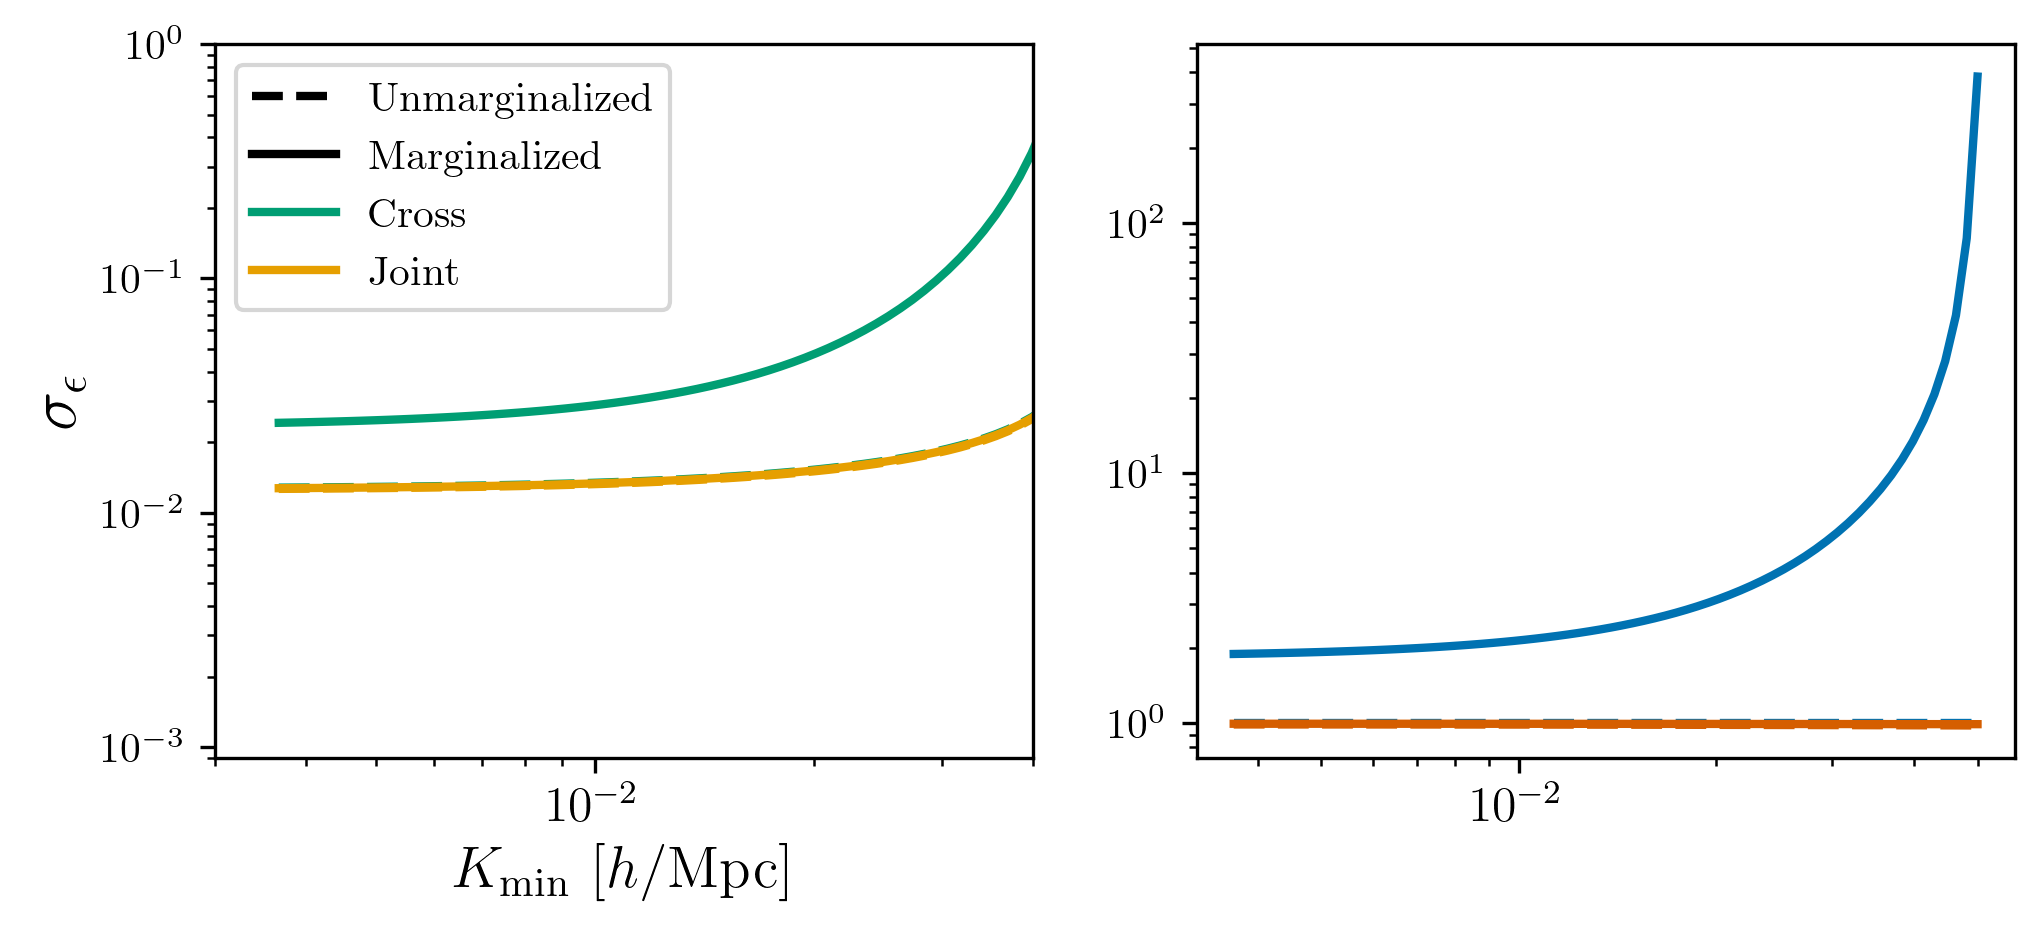

In [33]:
index = 0

from matplotlib.lines import Line2D

fig = plt.figure(figsize=(1.5*plot.FIG_WIDTH, plot.FIG_HEIGHT), dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 2, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

# Professional tick parameters
#ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
#               top=True, right=False)
#ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
#               top=True, right=False)
out_selected = out_results
out_selected = out_results_alt


keys = tuple(['modes', 'err_matrix', 'err_marginalized_matrix', 'err_matrix_cross', 'err_marginalized_matrix_cross'])
keybase = "base"
results = out_selected[keybase]
modes, err_matrix, err_marginalized_matrix, err_matrix_cross, err_marginalized_matrix_cross = [results[k] for k in keys]

color = lambda i: plot.COLORBLIND_PALETTE[i % len(plot.COLORBLIND_PALETTE)]

s1, s2 = 2, 5

base = 1#err_matrix_cross[:, index]
ax.loglog(modes, err_matrix_cross[:, index]/base, color = color(s1), ls = "--", lw=2)
ax.loglog(modes, err_marginalized_matrix_cross[:, index]/base, color = color(s1), lw=2)

ax.loglog(modes, err_matrix[:, index]/base, color = color(s2), ls = "--", lw=2)
ax.loglog(modes, err_marginalized_matrix[:, index]/base, color = color(s2), lw=2)

#ax.set_ylim(ymin = 2e-3, ymax = 1)
ax.set_ylim(ymin = 9e-4, ymax = 1)
ax.set_xlim(3e-3, 4e-2)
ax.set_xlabel(r'$K_{\mathrm{min}} \ [h/\mathrm{Mpc}]$', fontsize=14)
ax.set_ylabel(r'$\sigma_{\epsilon}$', fontsize=16)

legend_elements = [
    Line2D([0], [0], color = 'black', lw=2, linestyle='--', label='Unmarginalized'),
    Line2D([0], [0], color = 'black', lw=2, label='Marginalized'),
    Line2D([0], [0], color = color(s1), lw=2, label='Cross'),
    Line2D([0], [0], color = color(s2), lw=2, label='Joint')
]

ax.legend(handles=legend_elements, loc='best', fontsize=10)

ax = fig.add_subplot(gs[0, 1])

base = err_matrix_cross[:, index]
legend_elements = []

keybase = "only_asymm_shift"
results = out_selected[keybase]
modes, err_matrix, err_marginalized_matrix, err_matrix_cross, err_marginalized_matrix_cross = [results[k] for k in keys]
color_index = 0
ax.loglog(modes, err_matrix_cross[:, index]/base, color = color(color_index), ls = "--", lw=2)
ax.loglog(modes, err_marginalized_matrix_cross[:, index]/base, color = color(color_index), lw=2)
ax.loglog(modes, err_matrix[:, index]/base, color = color(color_index+1), ls = "--", lw=2)
ax.loglog(modes, err_marginalized_matrix[:, index]/base, color = color(color_index+1), lw=2)

legend_elements = [
    Line2D([0], [0], color = color(color_index), lw=2, label = 'Cross with $C^{S}_{[AB]}$ only'),
    Line2D([0], [0], color = color(color_index+1), lw=2, label = 'Joint with $C^{S}_{[AB]}$ only')
]

keybase = "growth_eps"
results = out_selected[keybase]
modes, err_matrix, err_marginalized_matrix, err_matrix_cross, err_marginalized_matrix_cross = [results[k] for k in keys]

color_index = 2
ax.loglog(modes, err_matrix_cross[:, index]/base, color = color(color_index), ls = "--", lw=2)
ax.loglog(modes, err_marginalized_matrix_cross[:, index]/base, color = color(color_index), lw=2)

ax.loglog(modes, err_matrix[:, index]/base, color = color(color_index+1), ls = "--", lw=2)
ax.loglog(modes, err_marginalized_matrix[:, index]/base, color = color(color_index+1), lw=2)

legend_elements += [
    Line2D([0], [0], color = color(color_index), lw=2, label = 'Cross with growth'),
    Line2D([0], [0], color = color(color_index+1), lw=2, label = 'Joint with growth')]


#keybase = "no_noise"
#results = out_results[keybase]
#modes, err_matrix, err_marginalized_matrix, err_matrix_cross, err_marginalized_matrix_cross = [results[k] for k in keys]
#color_index = 4
#ax.loglog(modes, err_matrix_cross[:, index]/base, color = color(color_index), ls = "--")
#ax.loglog(modes, err_marginalized_matrix_cross[:, index]/base, color = color(color_index))
#ax.loglog(modes, err_matrix[:, index]/base, color = color(color_index+1), ls = "--")
#ax.loglog(modes, err_marginalized_matrix[:, index]/base, color = color(color_index+1))
#legend_elements += [
#    Line2D([0], [0], color = color(color_index), lw=2, label = 'Cross no noise'),
#    Line2D([0], [0], color = color(color_index+1), lw=2, label = 'Joint no noise')]

#ax.set_ylim(ymin = 9e-4, ymax = 1)
ax.set_xlim(3e-3, 4e-2)

ax.set_ylabel(r'$\sigma_{\epsilon}/\sigma_{\epsilon,\mathrm{cross}}$', fontsize=16)
ax.set_xlabel(r'$K_{\mathrm{min}} \ [h/\mathrm{Mpc}]$', fontsize=14)



ax.legend(handles=legend_elements, loc='best', fontsize=10)


plt.subplots_adjust(wspace=0.3)
#fig.savefig(f"/users/odarwish/long-modes/figures/fisher_base.pdf", dpi = 300, bbox_inches='tight')
fig.tight_layout()
plt.show()
plt.close()

## Understanding constraints

## Cosmic variance cancellation

In [24]:
from copy import deepcopy

configurations_noise = {}

QR = qres.QEResults(config)

configuration_base = {"mainkey": "n",
                      "QR": QR,
                      "e": 0.,
                      "shot_noise": 1/config["number_density"]["nbar_A"], 
                      "variance_factor": 1., 
                      "bispectrum_factor": 0., 
                      "trispectrum_factor": 0., 
                      "asymm_shift": 1., #include asymm shift term or not. If 0, use only G, T asymm
                      "only_asymm_shift": 0., #only include asymm shift term or not, If 1, use only S asymm
                      "growth_eps": 0., #enhanced growth for galaxy clustering
                     }

N = 30
cases = [f"noise_{i}" for i in range(N)]
factors = np.array([np.exp(i)*1e-8 for i in range(N)])

factors = np.append(factors, 1)
cases.append(f"base")

for i, case in enumerate(cases):
    config_temp = deepcopy(configuration_base)
    config_temp["shot_noise"] *= factors[i]
    config_temp["variance_factor"] *= factors[i]
    configurations_noise[i] = config_temp

In [25]:
h = 0.67
V = 5  #100*h**3 #in Gpc h^{-3}
V_MPC3 = V*1e9
k_min_analysis = 2*np.pi/V_MPC3**(1/3)

##vA = jnp.array([0*e, b1A, b2A, bs2A, bGXA*0, bGXB*0, bSXA*0, bSXB*0, bTXA*0, bTXB*0]) #fiducial point
selected = [0, 1, 2, 3]#, 4, 5, 6]
selected_extended = [0, 1, 2, 3, 4, 5] #, 8, 9]
Narr = 1

out_results = {}
for k, conf in configurations_noise.items():
    F_cross, F_joint = get_full_fisher(**conf)
    modes, err_matrix, err_marginalized_matrix = ger_errors(F_joint, selected, k_min_analysis, Kmax, V, Narr = Narr)
    modes, err_matrix_cross, err_marginalized_matrix_cross = ger_errors(F_cross, selected, k_min_analysis, Kmax, V, Narr = Narr)

    modes, err_matrix_extended, err_marginalized_matrix_extended = ger_errors(F_joint, selected_extended, k_min_analysis, Kmax, V, Narr = Narr)
    modes, err_matrix_cross_extended, err_marginalized_matrix_cross_extended = ger_errors(F_cross, selected_extended, k_min_analysis, Kmax, V, Narr = Narr)

    temp_res = {"modes": modes, "err_matrix": err_matrix, "err_marginalized_matrix": err_marginalized_matrix, "err_matrix_cross": err_matrix_cross, "err_marginalized_matrix_cross": err_marginalized_matrix_cross}

    temp_res["err_matrix_extended"] = err_matrix_extended
    temp_res["err_marginalized_matrix_extended"] = err_marginalized_matrix_extended
    temp_res["err_matrix_cross_extended"] = err_matrix_cross_extended
    temp_res["err_marginalized_matrix_cross_extended"] = err_marginalized_matrix_cross_extended
    
    out_results[factors[k]] = temp_res
    out_results[factors[k]]["F_joint"] = F_joint
    out_results[factors[k]]["F_cross"] = F_cross
    print("Done", k)

Done 0
Done 1
Done 2
Done 3
Done 4
Done 5
Done 6
Done 7
Done 8
Done 9
Done 10
Done 11
Done 12
Done 13
Done 14
Done 15
Done 16
Done 17
Done 18
Done 19
Done 20
Done 21
Done 22
Done 23
Done 24
Done 25
Done 26
Done 27
Done 28
Done 29
Done 30


In [26]:
keys = tuple(['modes', 'err_matrix', 'err_marginalized_matrix', 'err_matrix_cross', 'err_marginalized_matrix_cross'])

index = 0
results = out_results[1]
modes, err_matrix, err_marginalized_matrix, err_matrix_cross, err_marginalized_matrix_cross = [results[k] for k in keys]
base = err_matrix_cross[:, index]

k = 'err_matrix_cross'
errors_noise_cross = np.array([out_results[f][k][:, index]/base for f in factors])
k = 'err_marginalized_matrix_cross'
errors_marginalized_noise_cross = np.array([out_results[f][k][:, index]/base for f in factors])
k = 'err_marginalized_matrix_cross_extended'
errors_marginalized_noise_cross_extended = np.array([out_results[f][k][:, index]/base for f in factors])

k = 'err_matrix'
errors_noise_joint = np.array([out_results[f][k][:, index]/base for f in factors])
k = 'err_marginalized_matrix'
errors_marginalized_noise_joint = np.array([out_results[f][k][:, index]/base for f in factors])
k = 'err_marginalized_matrix_extended'
errors_marginalized_noise_joint_extended = np.array([out_results[f][k][:, index]/base for f in factors])

#results = out_results[keybase]
#modes, err_matrix, err_marginalized_matrix, err_matrix_cross, err_marginalized_matrix_cross = [results[k] for k in keys]

/tmp/ipykernel_243744/1870607299.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


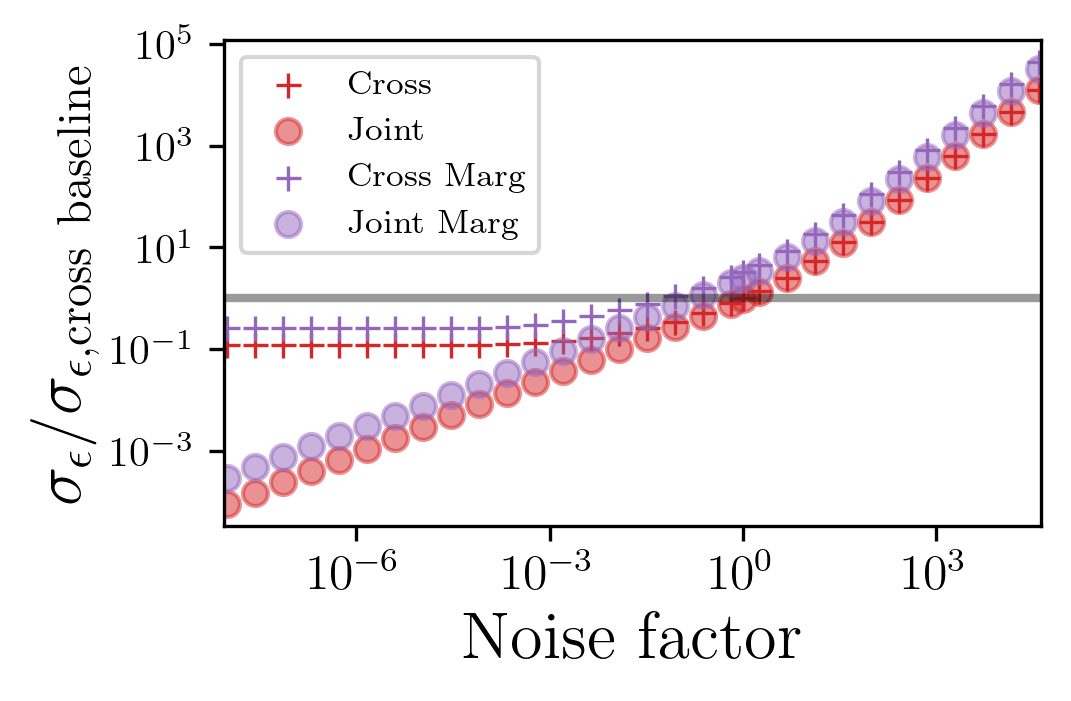

In [27]:
index = 0

from matplotlib.lines import Line2D

fig = plt.figure(figsize=plot.size, dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])


color = lambda i: plot.COLORBLIND_PALETTE_2[i]

ax.hlines(1, factors.min()*(1-0.1), factors.max()*(1+0.1), color = "black", lw = 2, alpha = 0.4)

i = 3
ax.scatter(factors, errors_noise_cross, label = "Cross", color = color(i), marker = "+")
ax.scatter(factors, errors_noise_joint, label = "Joint", color = color(i), alpha = 0.5)

i = 4
ax.scatter(factors, errors_marginalized_noise_cross, label = "Cross Marg", color = color(i), marker = "+")
#ax.scatter(factors, errors_marginalized_noise_cross_extended, label = "Cross Marg Extended", color = color(i), marker = "+")

ax.scatter(factors, errors_marginalized_noise_joint, label = "Joint Marg", color = color(i), alpha = 0.5)



ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylabel(r'$\sigma_{\epsilon}/\sigma_{\epsilon,\mathrm{cross\ baseline}}$', fontsize=16)
ax.set_xlabel(r'Noise factor', fontsize=16)

ax.set_xlim(factors.min()*(1-0.1), factors.max()*(1+0.1))
ax.legend(fontsize = 8)

plt.subplots_adjust(wspace=0.3)
fig.savefig(f"/users/odarwish/long-modes/figures/fisher_varying_noise.pdf", dpi = 300, bbox_inches='tight')
fig.tight_layout()
plt.show()
plt.close()

# Directly varying number density

In [30]:
import jax.numpy as jnp

import numpy as np

import pathlib


class QEResults:
    def __init__(self, config, sims = False, relative_path = "."):

        name_config = config['name']
        output_config = config['output']
        relative_path = pathlib.Path(relative_path)
        output_dir = relative_path / output_config['directory'] / name_config

        if sims:
            nome = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_normalization_AB.npy"
            nomev = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_variance_AB.npy"
            nometri = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_shot_trispectrum_AB.npy"
            nomebis_mixed = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_cross_shot_AB.npy"
            nomebis = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_shot_bispectrum_AB.npy"
        else:
            nome = f"analysis_theory_normalization_AB.npy"
            nomev = f"analysis_theory_variance_AB.npy"
            nomebis = f"analysis_theory_shot_bispectrum_AB.npy"
            nomebis_mixed = f"analysis_theory_cross_shot_AB.npy"
            nometri = f"analysis_theory_shot_trispectrum_AB.npy"

        self.out_normalization_AB = np.load(output_dir / nome, allow_pickle = True).item() #inverse of normalization N

        self.analysis_cross_shot_AB = np.load(output_dir / nomebis_mixed, allow_pickle = True).item() #cross shot-noise
        self.out_variance_AB = np.load(output_dir / nomev, allow_pickle = True).item() #variance
        self.out_shot_trispectrum = np.load(output_dir / nometri, allow_pickle = True).item() #trispectrum shot noise, assuming all the same
        self.out_shot_bispectrum = np.load(output_dir / nomebis, allow_pickle = True).item() #bispectrum shot noise, assuming all the same


        ps_main_directory = relative_path / config['power_spectrum']['main_directory']
        self.gen_nl_power = np.loadtxt(ps_main_directory/name_config/config['power_spectrum']['nonlinear'])
        self.gen_power = np.loadtxt(ps_main_directory/name_config/config['power_spectrum']['linear'])

        self.pnlinf = lambda kmag: jnp.interp(kmag, self.gen_nl_power[:,0], self.gen_nl_power[:,1])
        self.plinf = lambda kmag: jnp.interp(kmag, self.gen_power[:,0], self.gen_power[:,1])

        kr_config = config['k_range']
        kmin = kr_config['kmin']
        kmax = kr_config['kmax']
        k_samples = kr_config['k_samples']
        k_min_analysis = kr_config['k_min_analysis']
        k_max_analysis = kr_config['k_max_analysis']

        self.kmin = kmin
        self.kmax = kmax
        self.k_min_analysis = k_min_analysis
        self.k_max_analysis = k_max_analysis

        kmin_max = 2*k_min_analysis
        Ks_ = jnp.linspace(k_min_analysis, kmin_max, 20)
        Ks = jnp.logspace(jnp.log10(kmin_max), jnp.log10(k_max_analysis), k_samples)
        Ks = jnp.concatenate([Ks_, Ks])
        self.Ks = jnp.unique(Ks)

    def get_out_normalization_AB(self):
        result = {}
        for key, value in self.out_normalization_AB.items():
            value = np.array(value)
            value[np.abs(value)<1e-10] = 0
            result[key] = jnp.array(value)
        return result

    def get_get_norm(self):
        def get_norm(key):
            N = np.array(self.out_normalization_AB[(key, key)]**-1.)
            N[np.abs(N)>1e10] = 0
            N = jnp.array(N)
            return N
        return get_norm
    
    def get_get_variance(self):
        def get_variance(key):
            N = self.get_get_norm()(key)
            V = self.out_variance_AB[(key, key)]*N**2
            return V
        return get_variance
    
    def get_get_trispectrum(self):
        def get_trispectrum(key):
            N = self.get_get_norm()(key)
            T = self.out_shot_trispectrum[(key, key)]*N**2
            return T
        return get_trispectrum

    def get_get_bispectrum_mixed(self):
        def get_bispectrum_mixed(key):
            N = self.get_get_norm()(key)
            B = self.analysis_cross_shot_AB[(key, key)]*N
            return B
        return get_bispectrum_mixed

    def get_get_bispectrum(self):
        def get_bispectrum(key):
            N = self.get_get_norm()(key)
            B = self.out_shot_bispectrum[(key, key)]*N
            return B
        return get_bispectrum


    def get_get_tot_noises(self):
        def get_tot_noises(key):
            variance = self.get_get_variance()(key)
            bispectrum = self.get_get_bispectrum()(key)
            trispectrum = self.get_get_trispectrum()(key)
            bispectrum_mixed = self.get_get_bispectrum_mixed()(key)
            return variance, bispectrum, trispectrum, bispectrum_mixed

    @staticmethod
    def E_bottaro():
        z_eq = 3400
        a_eq = 1/(1+z_eq)
        a = 1.
        fchi = 1.
        factor = jnp.log(a/a_eq)-181/90
        factor *= fchi
        factor *= 6/5
        return factor

    def get_G(self):
        def G(epsilon, one = 1):
            E = self.E_bottaro()
            return 1+epsilon*E*one
        return G
    


def get_normalization_array(key, keys, Ks, out_normalization_AB):
    jax_out_normalization_AB = np.empty((len(keys), len(Ks)))
    for i, k in enumerate(keys):
        jax_out_normalization_AB[i, :] = out_normalization_AB[(key, k)]
    jax_out_normalization_AB = jnp.array(jax_out_normalization_AB)
    return jax_out_normalization_AB

In [29]:
from copy import deepcopy


selected = [0, 1, 2, 3]#, 4, 5, 6]
Narr = 1

out_results = {}
nbars = []

conf_indices = list(range(1, 32))

conf_vary_kmax_indices = list(range(25, 31))
nbars_kmax = []

conf_ok = []
for i in conf_indices:
    
    configuration_i = f'../../configs/abacus/desi_nbars/config_desi_base_{i}.yaml'

    with open(configuration_i, 'r') as f:
        config_i = yaml.safe_load(f)

    name = config_i["name"]
    path = f"../../results/{name}/"
    #path = f"/users/odarwish/results/desi_base_asymm/"
    
    try:
        QR = QEResults(config_i, relative_path = "../")
    except:
        print(i, "not found")
        continue

    if i not in conf_vary_kmax_indices:
        conf_ok.append(i)
        nbars.append(config_i["number_density"]["nbar_A"])
    else:
        nbars_kmax.append(config_i["number_density"]["nbar_A"])
    
    configuration_base_i = {"mainkey": "n",
                          "QR": QR,
                          "e": 0.,
                          "shot_noise": 1/config_i["number_density"]["nbar_A"], 
                          "variance_factor": 1., 
                          "bispectrum_factor": 0., 
                          "trispectrum_factor": 0., 
                          "asymm_shift": 1., #include asymm shift term or not. If 0, use only G, T asymm
                          "only_asymm_shift": 0., #only include asymm shift term or not, If 1, use only S asymm
                          "growth_eps": 0., #enhanced growth for galaxy clustering
                         }

    F_cross, F_joint = get_full_fisher(**configuration_base_i)
    modes, err_matrix, err_marginalized_matrix = ger_errors(F_joint, selected, k_min_analysis, Kmax, V, Narr = Narr)
    modes, err_matrix_cross, err_marginalized_matrix_cross = ger_errors(F_cross, selected, k_min_analysis, Kmax, V, Narr = Narr)
    out_results[i] = {"modes": modes, "err_matrix": err_matrix, "err_marginalized_matrix": err_marginalized_matrix, "err_matrix_cross": err_matrix_cross, "err_marginalized_matrix_cross": err_marginalized_matrix_cross}
    out_results[i]["F_joint"] = F_joint
    out_results[i]["F_cross"] = F_cross
    

7 not found
8 not found
9 not found


In [30]:
nbars = np.array(nbars)

keys = tuple(['modes', 'err_matrix', 'err_marginalized_matrix', 'err_matrix_cross', 'err_marginalized_matrix_cross'])

index = 0

argmin = np.argmin(abs(nbars-0.0018))
base_nbar_index = conf_ok[argmin]
results = out_results[base_nbar_index]
modes, err_matrix, err_marginalized_matrix, err_matrix_cross, err_marginalized_matrix_cross = [results[k] for k in keys]
base = err_matrix_cross[:, index]

k = 'err_matrix_cross'
errors_noise_cross_nbar = np.array([out_results[f][k][:, index]/base for f in conf_ok])
k = 'err_marginalized_matrix_cross'
errors_marginalized_noise_cross_nbar = np.array([out_results[f][k][:, index]/base for f in conf_ok])

k = 'err_matrix'
errors_noise_joint_nbar = np.array([out_results[f][k][:, index]/base for f in conf_ok])
k = 'err_marginalized_matrix'
errors_marginalized_noise_joint_nbar = np.array([out_results[f][k][:, index]/base for f in conf_ok])

k = 'err_marginalized_matrix'
errors_marginalized_noise_joint_nbar_kmax = np.array([out_results[f][k][:, index]/base for f in conf_vary_kmax_indices])

/tmp/ipykernel_243744/314226828.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


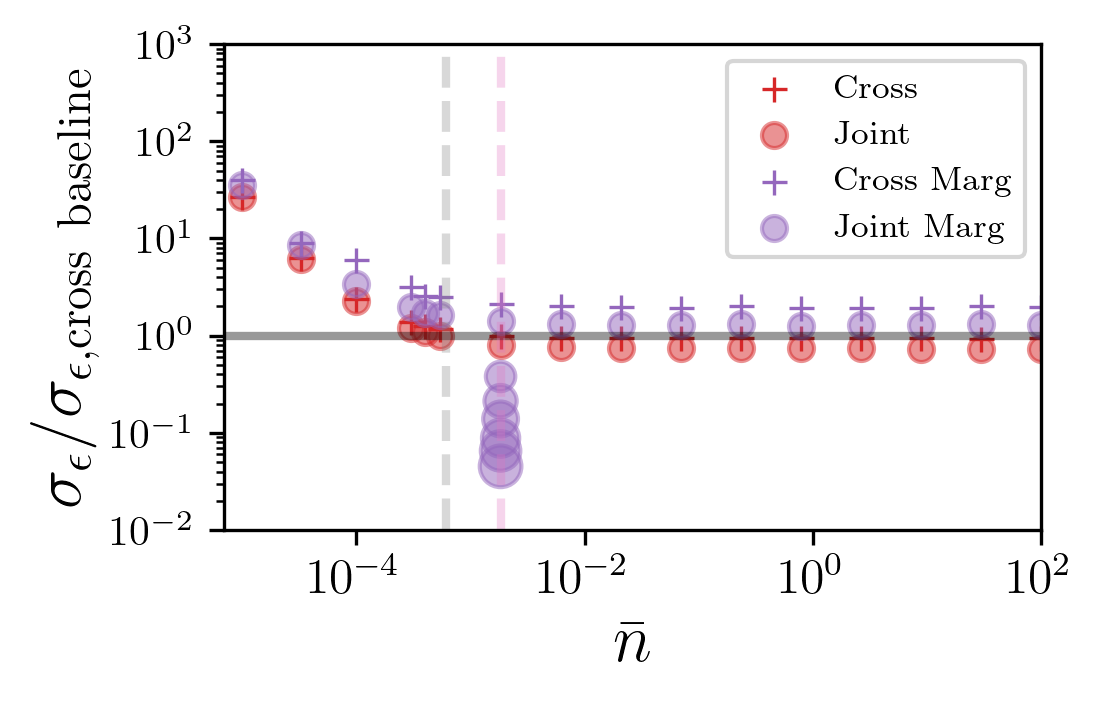

In [31]:
import matplotlib.cm as cm

index = 0

nbar_1 = nbars[argmin] #
nbar_2 = 1e-3 #
nbar_3 = 0.33*nbar_1

from matplotlib.lines import Line2D

fig = plt.figure(figsize=plot.size, dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

color = lambda i: plot.COLORBLIND_PALETTE_2[i]


ax.hlines(1, nbars.min()*(1-0.1), nbars.max()*(1+0.1), color = "black", lw = 2, alpha = 0.4)

ax.vlines(nbar_1, 1e-7, 2e3, color = color(6), ls = "--", lw = 2, alpha = 0.3)
#ax.vlines(nbar_2, 1e-7, 2e3, color = color(7), ls = "--", lw = 2, alpha = 0.3)
ax.vlines(nbar_3, 1e-7, 2e3, color = color(7), ls = "--", lw = 2, alpha = 0.3)


i = 3
ax.scatter(nbars, errors_noise_cross_nbar, label = "Cross", color = color(i), marker = "+")
ax.scatter(nbars, errors_noise_joint_nbar, label = "Joint", color = color(i), alpha = 0.5)

i = 4
ax.scatter(nbars, errors_marginalized_noise_cross_nbar, label = "Cross Marg", color = color(i), marker = "+")
ax.scatter(nbars, errors_marginalized_noise_joint_nbar, label = "Joint Marg", color = color(i), alpha = 0.5)


#ax.scatter(nbars_kmax, errors_marginalized_noise_joint_nbar_kmax, label = "Joint Marg Increasing $k_{\mathrm{max,rec}}$", color = color(5), alpha = 0.5)

n_kmax_points = len(nbars_kmax)
colors_kmax = cm.viridis(np.linspace(0.2, 0.8, n_kmax_points))  # or use cm.plasma, cm.coolwarm
#for i, (x, y) in enumerate(zip(nbars_kmax, errors_marginalized_noise_joint_nbar_kmax)):
#    ax.scatter(x, y, color=colors_kmax[i], alpha=0.7)

marker_sizes = np.linspace(50, 100, len(nbars_kmax))  # sizes increase with kmax
ax.scatter(nbars_kmax, errors_marginalized_noise_joint_nbar_kmax, 
           s=marker_sizes, color=color(i), alpha=0.5)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylabel(r'$\sigma_{\epsilon}/\sigma_{\epsilon,\mathrm{cross\ baseline}}$', fontsize=14)
ax.set_xlabel(r'$\bar{n}\ h^3\mathrm{[/Mpc^3]}$', fontsize=14)

ax.legend(fontsize = 8)

ax.set_xlim(nbars.min()*(1-0.1), nbars.max()*(1+0.1))
ax.set_xlim(7e-6, 100)
ax.set_ylim(1e-2, 1e3)

plt.subplots_adjust(wspace=0.3)
fig.savefig(f"/users/odarwish/long-modes/figures/fisher_varying_nbar.pdf", dpi = 300, bbox_inches='tight')
fig.tight_layout()
plt.show()
plt.close()